# Gigs Senior Data Analyst Challenge

Welcome to the Gigs data analyst take-home challenge! This notebook will help you get started with analyzing our connectivity usage data.

## About the Data

You'll be working with three main datasets:
- **Usage Data**: Detailed usage per subscription period (~100K+ records)
- **Plan Events**: Plan configuration and pricing history
- **Projects**: Project metadata

## Setup Instructions

Run the cells below to set up your environment and load the data into DuckDB.

In [1]:
# Import required libraries
import duckdb
import pandas as pd
from datetime import datetime, timedelta

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


In [2]:
# Load JupySQL extension and configure
%load_ext sql

# Configure JupySQL for better output
%config SqlMagic.autopandas = True
%config SqlMagic.feedback = False
%config SqlMagic.displaycon = False

print("✅ JupySQL configured!")

✅ JupySQL configured!


In [3]:
# Connect to DuckDB
conn = duckdb.connect('gigs-analytics.db')
%sql conn --alias duckdb

print("✅ Connected to DuckDB database: gigs-analytics.db")

✅ Connected to DuckDB database: gigs-analytics.db


In [4]:
%%sql
-- Load data into DuckDB tables
CREATE OR REPLACE TABLE usage_data AS 
SELECT * FROM 'data/usage_by_subscription_period.csv';

CREATE OR REPLACE TABLE plan_events AS 
SELECT * FROM 'data/plan_change_events.csv';

CREATE OR REPLACE TABLE projects AS 
SELECT * FROM 'data/projects.csv';

,Count
0,3


In [5]:
%%sql
-- Verify data loading
select 
  'usage_data' as table_name, 
  count(*) as row_count,
  count(distinct subscription_id) as unique_subscriptions
from usage_data
union all
select 
  'plan_events' as table_name, 
  count(*) as row_count,
  count(distinct plan_id) as unique_plans
from plan_events
union all
select 
  'projects' as table_name, 
  count(*) as row_count,
  count(distinct project_id__hashed) as unique_projects
from projects;

,table_name,row_count,unique_subscriptions
0,usage_data,53565,8457
1,plan_events,209,36
2,projects,3,3


## Your Analysis Starts Here!

Now you have everything set up. Use the cells below to start your analysis.

### Tips:
- Use `%%sql` for multi-line SQL queries
- Use `%sql variable_name <<` to store results in a Python variable
- Combine SQL with Python/Pandas for advanced analysis
- Feel free to use any visualisation library you feel comfortable with

---
---
# Start

#### Additional tools

In [6]:

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import plotly.express as px


# 1) Loading

### Lets see each table individually first

In [7]:
pro = pd.read_csv('data/projects.csv')
df = pd.read_csv('data/usage_by_subscription_period.csv')
plan = pd.read_csv('data/plan_change_events.csv')

#### 1) Projects table

In [8]:
pro.head()

,project_id__hashed,project_type,organization_name,device_type
0,dace2786aee7632e61757b320a6fe5bff37a2e742fe558...,API,People Mobile,Phones
1,82728d5d3cf7f35b58bc318399c2c5caf7eeadcc37f359...,Connect,ACME Phone,Phones
2,2aeca1a6c1ecf52b28b7f7646b6fb90563a417ee3e5dc3...,Connect,SmartDevices Inc.,Wearables


In [9]:
pro.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   project_id__hashed  3 non-null      object
 1   project_type        3 non-null      object
 2   organization_name   3 non-null      object
 3   device_type         3 non-null      object
dtypes: object(4)
memory usage: 224.0+ bytes


> Projects table is only indicatory

#### 2) Subscriptions table (usage_by_subscription_period)

> Since this is the main table i will use 'df' for pandas 

In [10]:
df.head(2)

,subscription_id,project_id__hashed,plan_id,reporting_date,subscription_period_start,subscription_period_end,subscription_period_number,cumulative_data_usage_megabyte,cumulative_voice_usage_minutes,cumulative_sms_usage,number_of_addons_activated
0,sub_b97107a1c7ef89cf28a7e83ee850,82728d5d3cf7f35b58bc318399c2c5caf7eeadcc37f359...,pln_0a3b55b9abb575b023c07e617b49,2024-02-07 00:00:00,2024-02-04,2024-02-07,1,0.000000,0.0,0.0,0
1,sub_2353ef9e8bf55916b97ceb30194c,82728d5d3cf7f35b58bc318399c2c5caf7eeadcc37f359...,pln_0a3b55b9abb575b023c07e617b49,2024-02-08 00:00:00,2024-01-25,2024-02-08,1,56.660992,1.0,1.0,0


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53565 entries, 0 to 53564
Data columns (total 11 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   subscription_id                 53565 non-null  object 
 1   project_id__hashed              53565 non-null  object 
 2   plan_id                         53565 non-null  object 
 3   reporting_date                  53565 non-null  object 
 4   subscription_period_start       53565 non-null  object 
 5   subscription_period_end         53565 non-null  object 
 6   subscription_period_number      53565 non-null  int64  
 7   cumulative_data_usage_megabyte  53565 non-null  float64
 8   cumulative_voice_usage_minutes  53565 non-null  float64
 9   cumulative_sms_usage            53565 non-null  float64
 10  number_of_addons_activated      53565 non-null  int64  
dtypes: float64(3), int64(2), object(6)
memory usage: 4.5+ MB


#### 3) Plan table (Plan_change_events)

In [12]:
plan.head(3)


,plan_id,project_id__hashed,plan_created_at,event_type,event_timestamp,plan_name,network_provider_id,price_currency,plan_price_amount_local,data_allowance_mb,is_unlimited_data,voice_allowance_seconds,is_unlimited_voice,sms_allowance,is_unlimited_sms,validity_value,validity_unit,_valid_from,_valid_to,_is_current_state
0,pln_b2a155624e05108d1a5b6b90f567,82728d5d3cf7f35b58bc318399c2c5caf7eeadcc37f359...,2023-12-29 18:43:12,plan.updated,2023-12-29 18:44:37.573698,Unlimited Data Plan,p4,USD,70.0,NaN,True,NaN,True,NaN,True,30,day,2023-12-29 18:44:37.573698,2023-12-29 18:44:37.846803,False
1,pln_b2a155624e05108d1a5b6b90f567,82728d5d3cf7f35b58bc318399c2c5caf7eeadcc37f359...,2023-12-29 18:43:12,plan.archived,2024-01-21 15:48:13.444971,Unlimited Data Plan,p4,USD,70.0,NaN,True,NaN,True,NaN,True,30,day,2024-01-21 15:48:13.444971,NaN,True
2,pln_b2a155624e05108d1a5b6b90f567,82728d5d3cf7f35b58bc318399c2c5caf7eeadcc37f359...,2023-12-29 18:43:12,plan.updated,2024-01-21 15:48:12.953812,Unlimited Data Plan,p4,USD,70.0,NaN,True,NaN,True,NaN,True,30,day,2024-01-21 15:48:12.953812,2024-01-21 15:48:13.444971,False


In [13]:
plan.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 209 entries, 0 to 208
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   plan_id                  209 non-null    object 
 1   project_id__hashed       209 non-null    object 
 2   plan_created_at          209 non-null    object 
 3   event_type               209 non-null    object 
 4   event_timestamp          209 non-null    object 
 5   plan_name                209 non-null    object 
 6   network_provider_id      209 non-null    object 
 7   price_currency           209 non-null    object 
 8   plan_price_amount_local  209 non-null    float64
 9   data_allowance_mb        120 non-null    float64
 10  is_unlimited_data        209 non-null    bool   
 11  voice_allowance_seconds  41 non-null     float64
 12  is_unlimited_voice       209 non-null    bool   
 13  sms_allowance            35 non-null     float64
 14  is_unlimited_sms         2

In [14]:
plan.groupby(['project_id__hashed','plan_id']).plan_price_amount_local.size().shape

(36,)

In [15]:
plan.duplicated().all(), df.duplicated().all() , pro.duplicated().all()

(np.False_, np.False_, np.False_)

# 2) DATA CHECKS




#### Quick sample of the data

In [16]:
def show_stats(df):
    for cols in df.columns:
        print(f"{cols} {'-'*(20-len(cols))}:  unique[{df[cols].nunique()}], null: {df[cols].isnull().sum()}, na:{df[cols].isna().sum()} \n samples --> {df[cols].unique()[:3]}", end="\n\n")

print('-----------------------------------------')
print('---------------- project ----------------')
print('-----------------------------------------\n\n')
show_stats(pro)
print('-----------------------------------------')
print('-----------------subscriptions-----------')
print('-----------------------------------------\n\n')
show_stats(df)
print('----------------------------------------------')
print('-----------------plan_change_events-----------')
print('----------------------------------------------\n\n')
show_stats(plan)



-----------------------------------------
---------------- project ----------------
-----------------------------------------


project_id__hashed --:  unique[3], null: 0, na:0 
 samples --> ['dace2786aee7632e61757b320a6fe5bff37a2e742fe5582c245665e3d0e3a84e'
 '82728d5d3cf7f35b58bc318399c2c5caf7eeadcc37f3597cb2817a9b5a87bbf3'
 '2aeca1a6c1ecf52b28b7f7646b6fb90563a417ee3e5dc32f9d1a50d7e8b9e13a']

project_type --------:  unique[2], null: 0, na:0 
 samples --> ['API' 'Connect']

organization_name ---:  unique[3], null: 0, na:0 
 samples --> ['People Mobile' 'ACME Phone' 'SmartDevices Inc.']

device_type ---------:  unique[2], null: 0, na:0 
 samples --> ['Phones' 'Wearables']

-----------------------------------------
-----------------subscriptions-----------
-----------------------------------------


subscription_id -----:  unique[8457], null: 0, na:0 
 samples --> ['sub_b97107a1c7ef89cf28a7e83ee850' 'sub_2353ef9e8bf55916b97ceb30194c'
 'sub_5d5605c8cf0b46116a42cedb9561']

project_id__hash

In [17]:
plan.event_type.unique()

array(['plan.updated', 'plan.archived', 'plan.published', 'plan.created'],
      dtype=object)

## Observations:

In general:

- There are no null values (except and sms allowance , which are not being used)
- There are no duplicates

Project: 

1. Its clean

Subscription: 

1. subscription start and end have different lenght, to check why.
1. cumulative data usage can be 0 
1. same for sms
  
Plan: 
1. voice_allowance_seconds , sms_allowance  could need some cleaning, but here we wont use it
1. plan archived could be use for churn
1. There are plan prices  that are 0 usd



## FAQs

In [18]:
%%sql

# can a subscription have multiple plans? - YES

SELECT 
subscription_id,
count(distinct plan_id) as total_plans
FROM usage_data
 group by 1
 order by 2 desc 
limit 2; 

,subscription_id,total_plans
0,sub_4ceac018aa0272b3a7e7e819e06f,3
1,sub_474c4a89091b44d5f662baef5623,3


In [19]:
%%sql

# example of a subscription with multiple plans
select 
* 
from usage_data

where subscription_id = 'sub_bf65d729c2df4092017eaea0ee0a';



,subscription_id,project_id__hashed,plan_id,reporting_date,subscription_period_start,subscription_period_end,subscription_period_number,cumulative_data_usage_megabyte,cumulative_voice_usage_minutes,cumulative_sms_usage,number_of_addons_activated
0,sub_bf65d729c2df4092017eaea0ee0a,82728d5d3cf7f35b58bc318399c2c5caf7eeadcc37f359...,pln_0a3b55b9abb575b023c07e617b49,2024-05-24,2024-04-25,2024-05-25,1,1829.331968,773.0,214.0,0
1,sub_bf65d729c2df4092017eaea0ee0a,82728d5d3cf7f35b58bc318399c2c5caf7eeadcc37f359...,pln_0a3b55b9abb575b023c07e617b49,2024-06-24,2024-05-25,2024-06-25,2,1488.722944,1761.0,484.0,0
2,sub_bf65d729c2df4092017eaea0ee0a,82728d5d3cf7f35b58bc318399c2c5caf7eeadcc37f359...,pln_0a3b55b9abb575b023c07e617b49,2024-07-24,2024-06-25,2024-07-25,3,1360.831488,1695.0,1205.0,0
3,sub_bf65d729c2df4092017eaea0ee0a,82728d5d3cf7f35b58bc318399c2c5caf7eeadcc37f359...,pln_0a3b55b9abb575b023c07e617b49,2024-08-24,2024-07-25,2024-08-25,4,1040.356352,1370.0,340.0,0
4,sub_bf65d729c2df4092017eaea0ee0a,82728d5d3cf7f35b58bc318399c2c5caf7eeadcc37f359...,pln_0a3b55b9abb575b023c07e617b49,2024-09-24,2024-08-25,2024-09-25,5,1449.269248,1179.0,243.0,0
5,sub_bf65d729c2df4092017eaea0ee0a,82728d5d3cf7f35b58bc318399c2c5caf7eeadcc37f359...,pln_0a3b55b9abb575b023c07e617b49,2024-10-24,2024-09-25,2024-10-25,6,1337.875456,1093.0,289.0,0
6,sub_bf65d729c2df4092017eaea0ee0a,82728d5d3cf7f35b58bc318399c2c5caf7eeadcc37f359...,pln_0a3b55b9abb575b023c07e617b49,2024-11-24,2024-10-25,2024-11-25,7,1284.484096,1306.0,443.0,0
7,sub_bf65d729c2df4092017eaea0ee0a,82728d5d3cf7f35b58bc318399c2c5caf7eeadcc37f359...,pln_af7b4a30086929d37e7f4eb3daed,2024-12-24,2024-11-25,2024-12-25,8,9843.621888,1300.0,553.0,0
8,sub_bf65d729c2df4092017eaea0ee0a,82728d5d3cf7f35b58bc318399c2c5caf7eeadcc37f359...,pln_1d3f49d61a672755efc1865c4d9a,2025-01-24,2024-12-25,2025-01-25,9,13642.873856,1021.0,229.0,0
9,sub_bf65d729c2df4092017eaea0ee0a,82728d5d3cf7f35b58bc318399c2c5caf7eeadcc37f359...,pln_1d3f49d61a672755efc1865c4d9a,2025-02-24,2025-01-25,2025-02-25,10,19221.571584,706.0,188.0,0


In [20]:
%%sql

# testing if overlapping periods are possible- To be check, the max subscription period should be the same as the count subscription periods, otherwise there are spaces or overlaps

select 
subscription_id,
plan_id,
max(subscription_period_number) as max_subscription_period_number,
count(distinct subscription_period_number) as counts_subscription_period_number
from usage_data
group by 1,2
having max_subscription_period_number != counts_subscription_period_number
limit 5;

,subscription_id,plan_id,max_subscription_period_number,counts_subscription_period_number
0,sub_94e55518b8a9d8e6c18108de13a6,pln_0a3b55b9abb575b023c07e617b49,14,8
1,sub_4dc0638221c6a6834a13603ccec4,pln_0a3b55b9abb575b023c07e617b49,15,9
2,sub_552e85f62a1fb73905fe369df752,pln_0a3b55b9abb575b023c07e617b49,7,5
3,sub_116bd510569a356d9abf0b69cf9a,pln_0a3b55b9abb575b023c07e617b49,13,12
4,sub_75d9698248e55f2213ba18bc3044,pln_0a3b55b9abb575b023c07e617b49,6,4


In [21]:
%%sql

# testing if overlapping periods are possible- To be check, the max subscription period is 15 but the total subscription periods is 9 which means there are spaces or overlaps

select 
subscription_id,

subscription_period_number
from usage_data
where subscription_id = 'sub_5fcce2fe700bf6bb70572b82e722'

,subscription_id,subscription_period_number
0,sub_5fcce2fe700bf6bb70572b82e722,2


In [22]:
%%sql 

# -- there are overlapping period_numbers  as well as missing periods Example in here

select 
* 
from usage_data

where subscription_id = 'sub_b05686892dcc5e429cde4571596c';





,subscription_id,project_id__hashed,plan_id,reporting_date,subscription_period_start,subscription_period_end,subscription_period_number,cumulative_data_usage_megabyte,cumulative_voice_usage_minutes,cumulative_sms_usage,number_of_addons_activated
0,sub_b05686892dcc5e429cde4571596c,82728d5d3cf7f35b58bc318399c2c5caf7eeadcc37f359...,pln_0a3b55b9abb575b023c07e617b49,2024-03-29,2024-02-29,2024-03-30,1,342.447104,144.0,172.0,0
1,sub_b05686892dcc5e429cde4571596c,82728d5d3cf7f35b58bc318399c2c5caf7eeadcc37f359...,pln_0a3b55b9abb575b023c07e617b49,2024-05-30,2024-04-30,2024-05-30,3,0.000000,0.0,0.0,0
2,sub_b05686892dcc5e429cde4571596c,82728d5d3cf7f35b58bc318399c2c5caf7eeadcc37f359...,pln_0a3b55b9abb575b023c07e617b49,2024-08-29,2024-07-31,2024-08-29,6,0.000000,0.0,0.0,0
3,sub_b05686892dcc5e429cde4571596c,82728d5d3cf7f35b58bc318399c2c5caf7eeadcc37f359...,pln_0a3b55b9abb575b023c07e617b49,2024-09-30,2024-08-29,2024-09-30,7,0.000000,0.0,0.0,0
4,sub_b05686892dcc5e429cde4571596c,82728d5d3cf7f35b58bc318399c2c5caf7eeadcc37f359...,pln_0a3b55b9abb575b023c07e617b49,2024-10-21,2024-09-30,2024-10-21,7,0.000000,0.0,0.0,0


In [23]:

%%sql
# can a subscription have multiple projects? - NO

SELECT 
subscription_id,
count(distinct project_id__hashed) as total_projects
FROM usage_data
group by 1

order by 2 desc 
limit 3; 

,subscription_id,total_projects
0,sub_043a43fcd6c9b339c71dc0a1981e,1
1,sub_9197e7499604b1192c196685b8ae,1
2,sub_7102b334d435ff3f96b10ba38f60,1


In [24]:
%%sql

-- is there a project that has much more plans? YES

select 

distinct project_id__hashed,   count(distinct plan_id)

from  plan_events
group by 1  order by 2 desc 

,project_id__hashed,count(DISTINCT plan_id)
0,dace2786aee7632e61757b320a6fe5bff37a2e742fe558...,26
1,82728d5d3cf7f35b58bc318399c2c5caf7eeadcc37f359...,6
2,2aeca1a6c1ecf52b28b7f7646b6fb90563a417ee3e5dc3...,4


In [25]:
plan.groupby(['project_id__hashed'])['plan_id'].nunique().reset_index()

,project_id__hashed,plan_id
0,2aeca1a6c1ecf52b28b7f7646b6fb90563a417ee3e5dc3...,4
1,82728d5d3cf7f35b58bc318399c2c5caf7eeadcc37f359...,6
2,dace2786aee7632e61757b320a6fe5bff37a2e742fe558...,26


# 3) Solving the Questions:

## Q1 : How much data does a subscription typically consume?


Thoughts:
  
This questions is vague thus it depends by the perspective. Unfortunatelly we dont know which team is asking this question (finance, customer service, ...)

TO DO:  
  1. First lets find the data consumption 
  1. Join with the plan using plan_id and project to have all dimensions
  1. Because there are gaps in the period progression AND repited numbers, use count.  
  1. There could be empty usage months, thus we take out from the calculation
  1. There could be many dimensions to calculate the avg, such as  per project, per plan, device, etc. but since is not explicitly asked we take the globla view.
  1. A subscription could have several plans, for simplicity we will only use subscriptions that have finished all plans.
    
  

In [26]:
%%sql

WITH 

 
subscription_usage AS (
  
  SELECT 
    a.project_id__hashed,
    a.subscription_id,
    COUNT(a.subscription_period_number) AS count_periods,
    SUM(a.cumulative_data_usage_megabyte) AS sum_data_usage,
    SUM(a.cumulative_data_usage_megabyte) / COUNT(a.subscription_period_number) as avg_usage
  FROM 
    usage_data as a 
  
    
  GROUP BY 1,2
  HAVING sum_data_usage > 0 
  
)
  
  
SELECT 
 sum(sum_data_usage)/sum(count_periods) global_avg,
 median(avg_usage) as median_avg, 
 min(avg_usage) as min_usage,
 max(avg_usage) as max_usage,
 PERCENTILE_CONT(0.25) WITHIN GROUP( ORDER BY sum_data_usage) as p25_usage,
 PERCENTILE_CONT(0.50) WITHIN GROUP( ORDER BY sum_data_usage) as p50_usage,
 PERCENTILE_CONT(0.75) WITHIN GROUP( ORDER BY sum_data_usage) as p75_usage,
 PERCENTILE_CONT(0.80) WITHIN GROUP( ORDER BY sum_data_usage) as p80_usage,
 PERCENTILE_CONT(0.95) WITHIN GROUP( ORDER BY sum_data_usage) as p95_usage,
 COUNT(subscription_id) as count_subscriptions

FROM
  subscription_usage



,global_avg,median_avg,min_usage,max_usage,p25_usage,p50_usage,p75_usage,p80_usage,p95_usage,count_subscriptions
0,1515.311922,251.026725,0.00064,237214.058496,337.981235,1536.419521,5392.75264,7730.907341,42042.217882,7560


In [27]:
subscription_usage = conn.execute("""
WITH 

 
subscription_usage AS (
  
  SELECT 
    a.project_id__hashed,
    a.subscription_id,
    COUNT(a.subscription_period_number) AS count_periods,
    SUM(a.cumulative_data_usage_megabyte) AS sum_data_usage,
    SUM(a.cumulative_data_usage_megabyte) / COUNT(a.subscription_period_number) as avg_usage
  FROM 
    usage_data as a 
  
    
  GROUP BY 1,2
  HAVING sum_data_usage > 0 
  
)
  
  
SELECT 
*

FROM
  subscription_usage

""").df()

subscription_usage .head(2)

,project_id__hashed,subscription_id,count_periods,sum_data_usage,avg_usage
0,82728d5d3cf7f35b58bc318399c2c5caf7eeadcc37f359...,sub_79028c07c5eb4e64ad1f23ac7d57,8,62.924800,7.865600
1,82728d5d3cf7f35b58bc318399c2c5caf7eeadcc37f359...,sub_b31d73742aa9431346bc19f5912b,3,52.355072,17.451691


#### Lets visualize the average usage

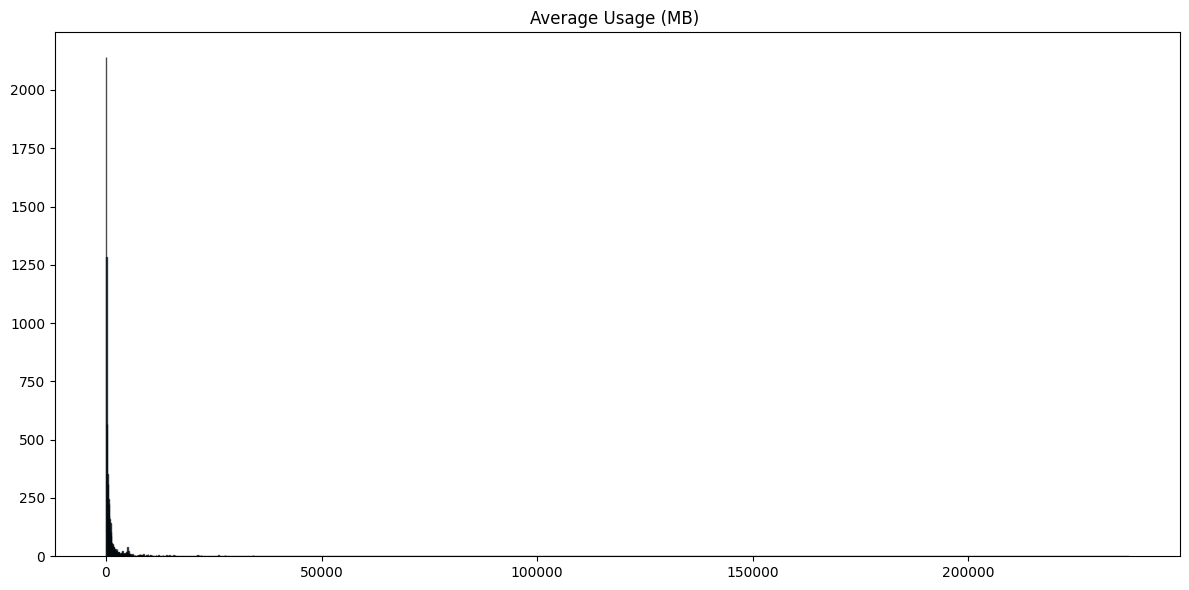

In [28]:
plt.figure(figsize=(12, 6))

# Histogram
ax1 = plt.subplot(1, 1, 1)
ax1.hist(subscription_usage['avg_usage'], bins='auto', alpha=0.7, edgecolor='black')

plt.title('Average Usage (MB) ')
plt.tight_layout()
plt.show()

#### Its hard to see the others so lets use log scale to make it 

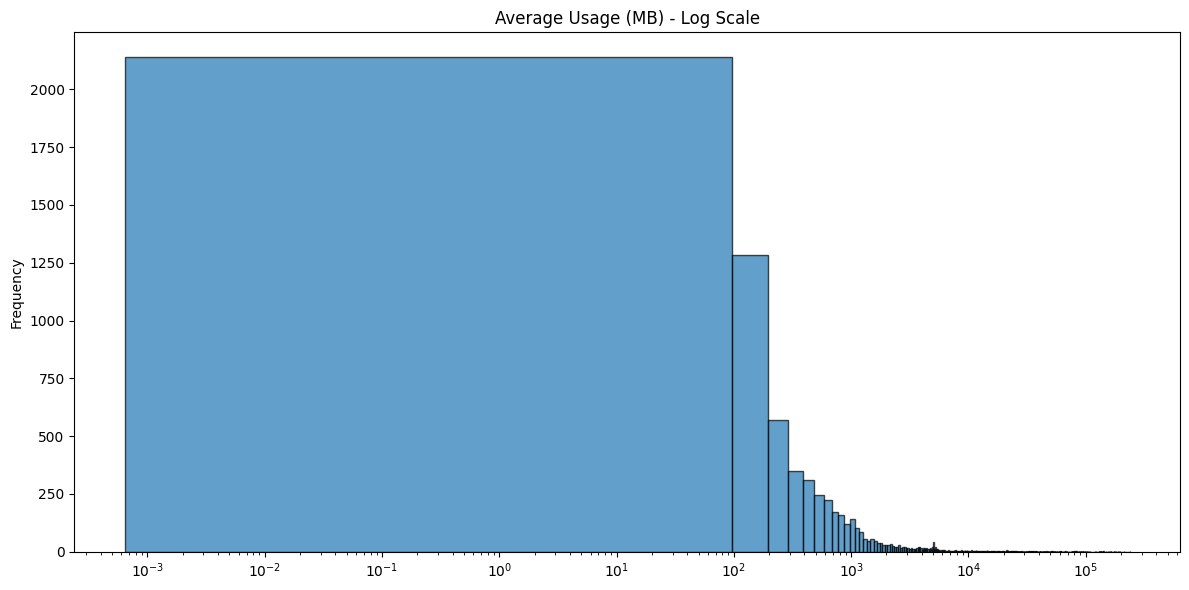

In [29]:
plt.figure(figsize=(12, 6))

# Histogram
ax1 = plt.subplot(1, 1, 1)
ax1.hist(subscription_usage['avg_usage'], bins='auto', alpha=0.7, edgecolor='black')
ax1.set_xscale('log')  # Log scale on x-axis
ax1.set_ylabel('Frequency')

plt.title('Average Usage (MB) - Log Scale')
plt.tight_layout()
plt.show()

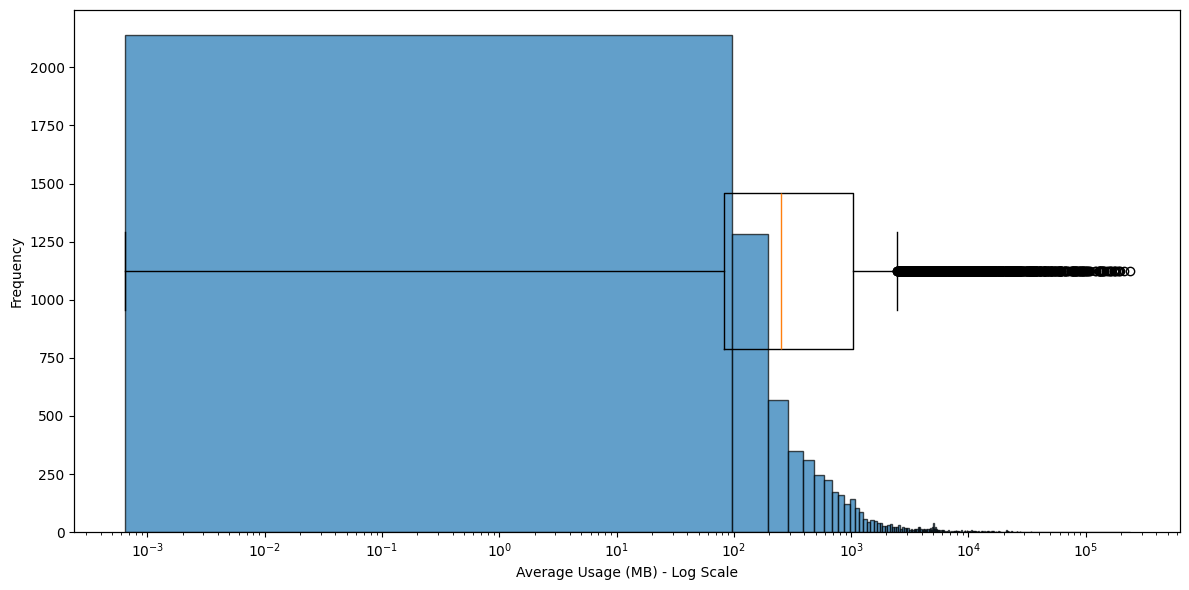

In [30]:
plt.figure(figsize=(12, 6))

# Histogram
ax1 = plt.subplot(1, 1, 1)
ax1.hist(subscription_usage['avg_usage'], bins='auto', alpha=0.7, edgecolor='black')
ax1.set_xscale('log')  # Log scale on x-axis
ax1.set_xlabel('Average Usage (MB) - Log Scale')
ax1.set_ylabel('Frequency')

# Boxplot overlaid
ax2 = ax1.twinx()
ax2.boxplot(subscription_usage['avg_usage'], vert=False, widths=0.3)
ax2.set_xscale('log')  # Also set log on the twin axis
ax2.set_yticks([])

plt.tight_layout()
plt.show()

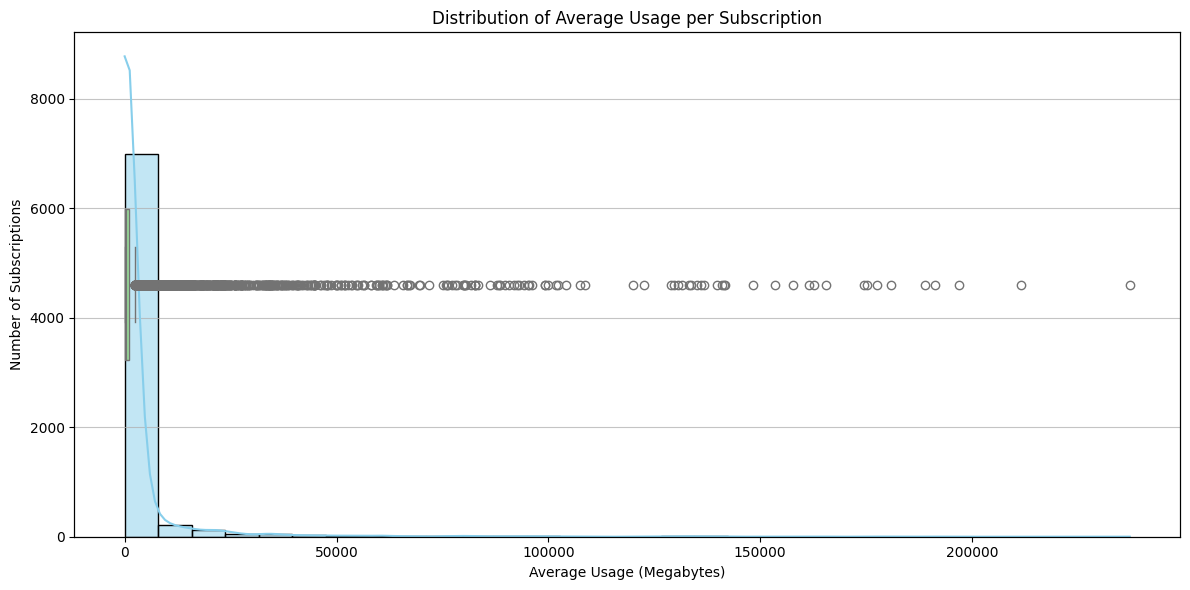

In [31]:
plt.figure(figsize=(12, 6))

# Histogram with KDE
ax1 = plt.subplot(1, 1, 1)
sns.histplot(subscription_usage['avg_usage'], bins=30, kde=True, color='skyblue', edgecolor='black', ax=ax1)
ax1.set_title('Distribution of Average Usage per Subscription')
ax1.set_xlabel('Average Usage (Megabytes)')
ax1.set_ylabel('Number of Subscriptions')
ax1.grid(axis='y', alpha=0.75)

# Horizontal box plot (on a separate y-axis)
ax2 = ax1.twinx()
sns.boxplot(x=subscription_usage['avg_usage'], orient='h', color='lightgreen', width=0.3, ax=ax2)
ax2.set_yticks([])
ax2.set_xlabel('')

plt.tight_layout()
plt.show()

#### This is a almost perfect view but lets make one that resumes the information better

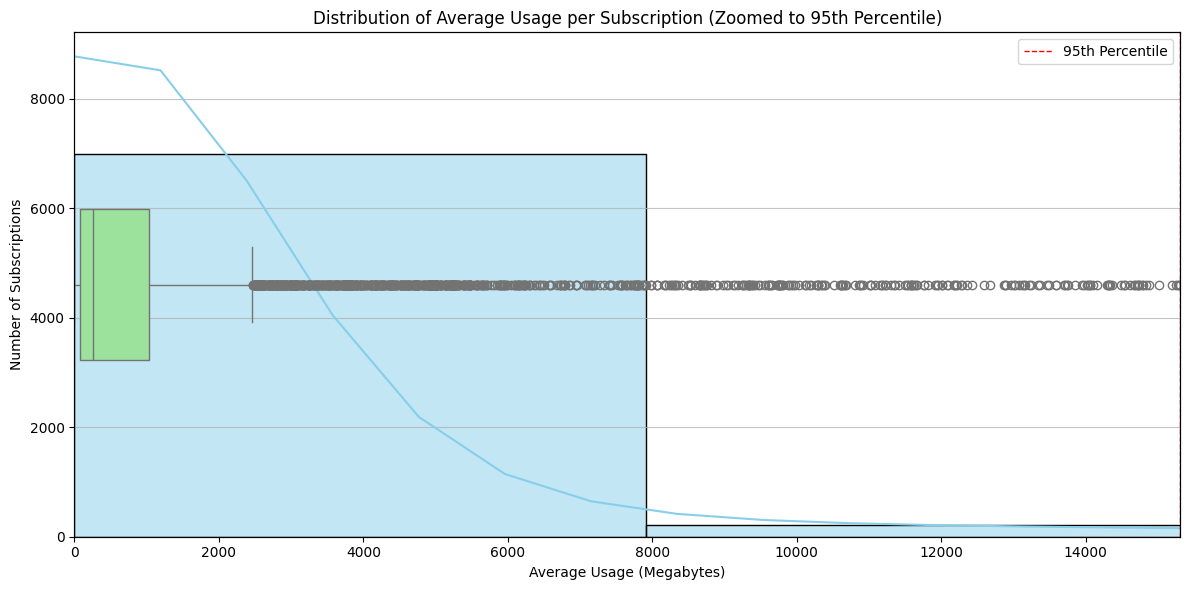

In [32]:
import numpy as np

# Calculate the 95th percentile
percentile_95 = np.percentile(subscription_usage['avg_usage'], 95)

# Create the figure and axes
plt.figure(figsize=(12, 6))

# Histogram with KDE
ax1 = plt.subplot(1, 1, 1)
sns.histplot(subscription_usage['avg_usage'], bins=30, kde=True, color='skyblue', edgecolor='black', ax=ax1)
ax1.set_title('Distribution of Average Usage per Subscription (Zoomed to 95th Percentile)')
ax1.set_xlabel('Average Usage (Megabytes)')
ax1.set_ylabel('Number of Subscriptions')
ax1.grid(axis='y', alpha=0.75)
ax1.set_xlim(0, percentile_95)  # Zoom to 95th percentile

# Horizontal box plot (on a separate y-axis)
ax2 = ax1.twinx()
sns.boxplot(x=subscription_usage['avg_usage'], orient='h', color='lightgreen', width=0.3, ax=ax2)
ax2.set_yticks([])
ax2.set_xlim(0, percentile_95)  # Match the zoom
ax2.set_xlabel('')

# Optionally, add a vertical line at the 95th percentile
ax1.axvline(percentile_95, color='red', linestyle='--', linewidth=1, label='95th Percentile')
ax1.legend()

plt.tight_layout()
plt.show()


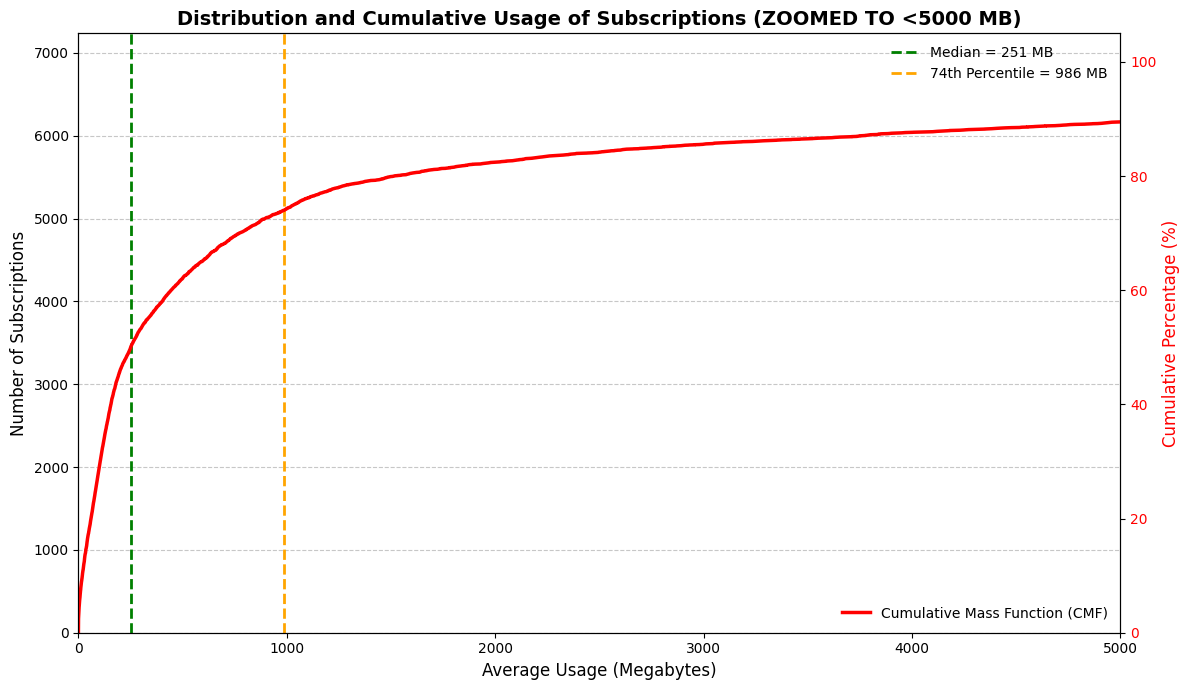

In [33]:
plt.figure(figsize=(12, 7))

# Sort and compute CMF
data = subscription_usage['avg_usage'].dropna()
sorted_usage = np.sort(data)
cmf = np.arange(1, len(sorted_usage) + 1) / len(sorted_usage) * 100

# Create main histogram with KDE
ax1 = sns.histplot(
    data,
    bins=40, 
    edgecolor='white',
    alpha=0.0
)
ax1.set_xlim(0, 5000)
ax1.set_xlabel('Average Usage (Megabytes)', fontsize=12)
ax1.set_ylabel('Number of Subscriptions', fontsize=12)
ax1.set_title('Distribution and Cumulative Usage of Subscriptions (ZOOMED TO <5000 MB)', fontsize=14, weight='bold')
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# Add CMF (secondary y-axis)
ax2 = ax1.twinx()
ax2.plot(sorted_usage, cmf, color='red', linewidth=2.5, label='Cumulative Mass Function (CMF)')
ax2.set_xlim(0, 5000)
ax2.set_ylim(0, 105)
ax2.set_ylabel('Cumulative Percentage (%)', color='red', fontsize=12)
ax2.tick_params(axis='y', labelcolor='red')
ax2.legend(loc='lower right', frameon=False)

# Add median and percentile markers
median_val = np.median(data)
p74_val = np.percentile(data, 74)
ax1.axvline(median_val, color='green', linestyle='--', linewidth=2, label=f'Median = {median_val:.0f} MB')
ax1.axvline(p74_val, color='orange', linestyle='--', linewidth=2, label=f'74th Percentile = {p74_val:.0f} MB')
ax1.legend(loc='upper right', frameon=False)

plt.tight_layout()
plt.show()


### ANSWER:

Short Answer: The median consumption is around 298 mb

Long Answer:
 The median and average are far appart showing that there are many outliers and a lot of subscriptions that havent done much consumption. 
 You take a big chunk of subscriptions usage if it lies less than ~1000mb  (easy to remember)
 

---

## Q2:  How does usage look like at different plan data allowances?

In [34]:
plan.groupby(['plan_name','data_allowance_mb']).size()

plan_name           data_allowance_mb
5GB                 5000.0               20
5GB Plan            5000.0               27
5GB Test Plan       5000.0                2
Basic Plan          5000.0                4
Easy Plan           1000.0               13
No Allowances Plan  0.0                  31
Plus Plan           5000.0               13
SMS Only Plan       0.0                  10
dtype: int64

> Here we do filter by plan

In [35]:
%%sql
SELECT
    plan_name,
    network_provider_id,
    is_unlimited_data,
    voice_allowance_seconds,
    is_unlimited_voice,
    sms_allowance,
    is_unlimited_sms,
    COUNT(*) AS count
FROM
    plan
GROUP BY
    plan_name,
    network_provider_id,
    is_unlimited_data,
    voice_allowance_seconds,
    is_unlimited_voice,
    sms_allowance,
    is_unlimited_sms
ORDER BY
    count DESC;

,plan_name,network_provider_id,is_unlimited_data,voice_allowance_seconds,is_unlimited_voice,sms_allowance,is_unlimited_sms,count
0,Ultra Unlimited,p11,True,NaN,True,NaN,True,33
1,No Allowances Plan,p11,False,0.0,False,0.0,False,31
2,Unlimited Plan,p11,True,NaN,True,NaN,True,30
3,5GB Plan,p11,False,NaN,True,NaN,True,27
4,5GB,p11,False,NaN,True,NaN,True,20
5,Unlimited Plan,p13,True,NaN,True,NaN,True,11
6,Unlimited Data Plan,p9,True,NaN,True,NaN,True,9
7,Plus Plan,p9,False,NaN,True,NaN,True,8
8,Easy Plan,p9,False,NaN,True,NaN,True,8
9,SMS Only Plan,p11,False,0.0,False,NaN,True,6


In [36]:
%%sql

WITH 

 

subscription_usage AS (
  
  SELECT 
   
    c.plan_name,
    a.plan_id,
    a.subscription_id,
    COUNT(a.subscription_period_number) AS count_periods,
    SUM(a.cumulative_data_usage_megabyte) AS sum_data_usage,
    SUM(a.cumulative_data_usage_megabyte) / COUNT(a.subscription_period_number) as avg_usage
  FROM 
    usage_data as a
  
  INNER JOIN 
    plan_events as c
    on a.plan_id = c.plan_id
    AND a.project_id__hashed = c.project_id__hashed
    
  GROUP BY 1,2,3
  HAVING sum_data_usage > 0 
  
)

  
SELECT 
 -- dimnensions
 plan_name,
 
 -- calcuations
 sum(sum_data_usage)/sum(count_periods) global_avg,
 median(avg_usage) as median_avg, 
 min(avg_usage) as min_usage,
 max(avg_usage) as max_usage,
 PERCENTILE_CONT(0.25) WITHIN GROUP( ORDER BY sum_data_usage) as p25_usage,
 PERCENTILE_CONT(0.50) WITHIN GROUP( ORDER BY sum_data_usage) as p50_usage,
 PERCENTILE_CONT(0.75) WITHIN GROUP( ORDER BY sum_data_usage) as p75_usage,
 PERCENTILE_CONT(0.80) WITHIN GROUP( ORDER BY sum_data_usage) as p80_usage,
 PERCENTILE_CONT(0.95) WITHIN GROUP( ORDER BY sum_data_usage) as p95_usage,
 COUNT(subscription_id) as count_subscriptions

FROM
  subscription_usage
GROUP BY 
  plan_name

,plan_name,global_avg,median_avg,min_usage,max_usage,p25_usage,p50_usage,p75_usage,p80_usage,p95_usage,count_subscriptions
0,5GB Plan,9.337856,9.337856,9.337856,9.337856,112.054272,112.054272,112.054272,112.054272,1.120543e+02,1
1,5GB,2814.728004,4550.743552,0.001024,5766.160384,385.910784,19033.552896,20001.310720,20004.945920,2.102689e+04,92
2,Ultra Unlimited,37842.720536,23298.586624,0.001024,237214.058496,42046.597120,122475.105280,270317.050880,350199.991091,7.064085e+05,425
3,Plus Plan,1765.223080,606.526135,0.001303,86537.450837,2464.708608,18649.829376,89842.413568,121887.483494,2.936403e+05,522
4,No Allowances Plan,4416.281441,295.672832,0.171008,80762.446848,366.425600,1478.364160,11596.367360,17426.220032,8.998884e+04,58
5,Basic Plan,1423.908847,765.136530,0.001516,9140.748564,1321.758846,3929.340596,14173.966174,17828.235851,2.369254e+04,275
6,Unlimited Data Plan,9208.251851,3835.035136,0.014336,167558.815488,10930.240512,131760.248832,562335.519744,788223.058330,2.393325e+06,577
7,Unlimited Plan,3219.753433,1507.249141,0.000120,23150.351636,2269.309311,9576.986964,26441.174724,33518.693051,8.497278e+04,744
8,Easy Plan,392.566450,167.013402,0.000640,54535.297638,2313.072640,9902.125056,27728.629760,35727.969485,9.330965e+04,5414


In [37]:
result = conn.execute("""
WITH 

 

subscription_usage AS (
  
  SELECT 
   
    c.plan_name,
    a.plan_id,
    a.subscription_id,
    COUNT(a.subscription_period_number) AS count_periods,
    SUM(a.cumulative_data_usage_megabyte) AS sum_data_usage,
    SUM(a.cumulative_data_usage_megabyte) / COUNT(a.subscription_period_number) as avg_usage
  FROM 
    usage_data as a
  
  INNER JOIN 
    plan_events as c
    on a.plan_id = c.plan_id
    AND a.project_id__hashed = c.project_id__hashed
    
  GROUP BY 1,2,3
  HAVING sum_data_usage > 0 
  
)

  
SELECT 
 -- dimnensions
 plan_name,
 
 -- calcuations
 sum(sum_data_usage)/sum(count_periods) global_avg,
 median(avg_usage) as median_avg, 
 min(avg_usage) as min_usage,
 max(avg_usage) as max_usage,
 PERCENTILE_CONT(0.25) WITHIN GROUP( ORDER BY sum_data_usage) as p25_usage,
 PERCENTILE_CONT(0.50) WITHIN GROUP( ORDER BY sum_data_usage) as p50_usage,
 PERCENTILE_CONT(0.75) WITHIN GROUP( ORDER BY sum_data_usage) as p75_usage,
 PERCENTILE_CONT(0.80) WITHIN GROUP( ORDER BY sum_data_usage) as p80_usage,
 PERCENTILE_CONT(0.95) WITHIN GROUP( ORDER BY sum_data_usage) as p95_usage,
 COUNT(subscription_id) as count_subscriptions

FROM
  subscription_usage
GROUP BY 
  plan_name

""").df()

result.head(2)

,plan_name,global_avg,median_avg,min_usage,max_usage,p25_usage,p50_usage,p75_usage,p80_usage,p95_usage,count_subscriptions
0,5GB Plan,9.337856,9.337856,9.337856,9.337856,112.054272,112.054272,112.054272,112.054272,112.054272,1
1,Basic Plan,1423.908847,765.136530,0.001516,9140.748564,1321.758846,3929.340596,14173.966174,17828.235851,23692.535757,275


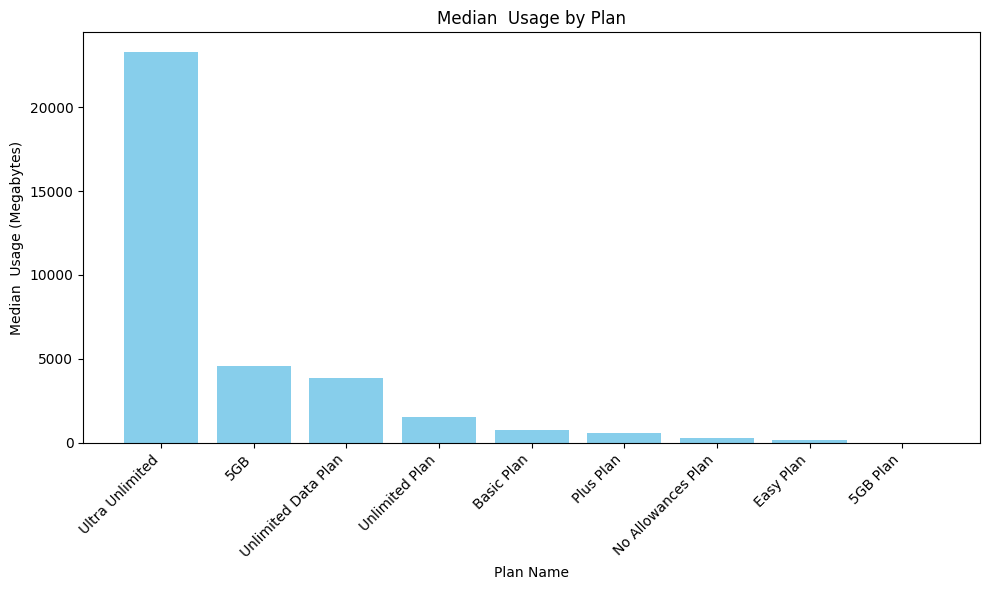

In [38]:

# Sort by median_avg for better visualization (optional)
result_sorted = result.sort_values('median_avg', ascending=False)

# Create the bar plot
plt.figure(figsize=(10, 6))
plt.bar(result_sorted['plan_name'], result_sorted['median_avg'], color='skyblue')

# Add labels and title
plt.title('Median  Usage by Plan')
plt.xlabel('Plan Name')
plt.ylabel('Median  Usage (Megabytes)')
plt.xticks(rotation=45, ha='right')  # Rotate x-labels for readability
plt.tight_layout()  # Adjust layout to prevent label cutoff
plt.show()

> There is a noticeable difference in usage with unlimited data. Lets dig a bit more

In [39]:

subscription_usage = (
    df.merge(plan, on=['plan_id', 'project_id__hashed'], how='inner')
)

subscription_usage = (
    subscription_usage.groupby(['plan_name', 'plan_id', 'subscription_id', 'network_provider_id'], as_index=False)
    .agg(
        count_periods=('subscription_period_number', 'count'),
        sum_data_usage=('cumulative_data_usage_megabyte', 'sum')
    )
)
 
subscription_usage['avg_usage'] = (
    subscription_usage['sum_data_usage'] / subscription_usage['count_periods']
)
 
subscription_usage = subscription_usage[subscription_usage['sum_data_usage'] > 0]
 
def percentile(x, q):
    return np.percentile(x, q)

summary = (
    subscription_usage.groupby(['plan_name', 'network_provider_id'], as_index=False)
    .agg(
        global_avg=('sum_data_usage', lambda x: x.sum() / subscription_usage.loc[x.index, 'count_periods'].sum()),
        median_avg=('avg_usage', 'median'),
        min_usage=('avg_usage', 'min'),
        max_usage=('avg_usage', 'max'),
        p25_usage=('sum_data_usage', lambda x: percentile(x, 25)),
        p50_usage=('sum_data_usage', lambda x: percentile(x, 50)),
        p75_usage=('sum_data_usage', lambda x: percentile(x, 75)),
        p80_usage=('sum_data_usage', lambda x: percentile(x, 80)),
        p95_usage=('sum_data_usage', lambda x: percentile(x, 95)),
        count_subscriptions=('subscription_id', 'count'), 
    )
)
summary

,plan_name,network_provider_id,global_avg,median_avg,min_usage,max_usage,p25_usage,p50_usage,p75_usage,p80_usage,p95_usage,count_subscriptions
0,5GB,p11,2814.728004,4550.743552,0.001024,5766.160384,385.910784,19033.552896,20001.310720,20004.945920,2.102689e+04,92
1,5GB Plan,p11,9.337856,9.337856,9.337856,9.337856,112.054272,112.054272,112.054272,112.054272,1.120543e+02,1
2,Basic Plan,p13,1423.908847,765.136530,0.001516,9140.748564,1321.758846,3929.340596,14173.966174,17828.235851,2.369254e+04,275
3,Easy Plan,p9,392.566450,167.013402,0.000640,54535.297638,2313.072640,9902.125056,27728.629760,35727.969485,9.330965e+04,5414
4,No Allowances Plan,p11,4416.281441,295.672832,0.171008,80762.446848,366.425600,1478.364160,11596.367360,17426.220032,8.998884e+04,58
5,Plus Plan,p9,1765.223080,606.526135,0.001303,86537.450837,2464.708608,18649.829376,89842.413568,121887.483494,2.936403e+05,522
6,Ultra Unlimited,p11,37842.720536,23298.586624,0.001024,237214.058496,42046.597120,122475.105280,270317.050880,350199.991091,7.064085e+05,425
7,Unlimited Data Plan,p9,9208.251851,3835.035136,0.014336,167558.815488,10930.240512,131760.248832,562335.519744,788223.058330,2.393325e+06,577
8,Unlimited Plan,p13,3219.753433,1507.249141,0.000120,23150.351636,2269.309311,9576.986964,26441.174724,33518.693051,8.497278e+04,744


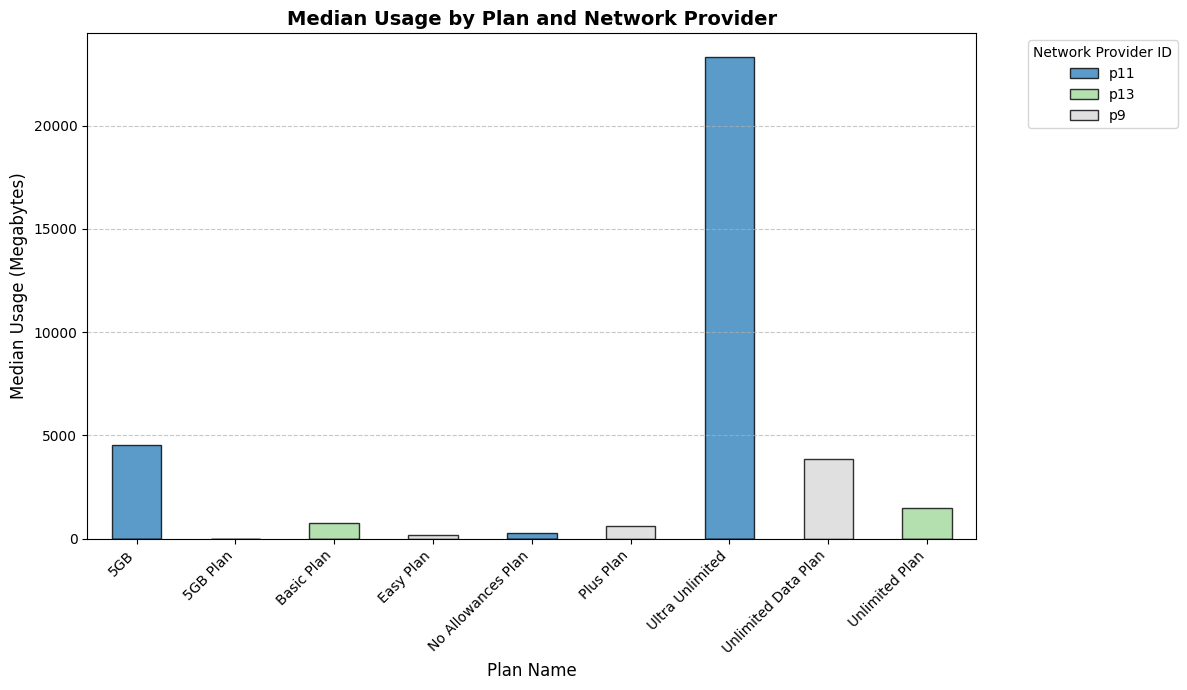

In [40]:
result_sorted = summary.sort_values('median_avg', ascending=False)

plan_totals = summary.groupby('plan_name')['median_avg'].sum().sort_values(ascending=False)

# Pivot data to get network_provider_id as columns (for stacked colors)
pivot_data = result_sorted.pivot(
    index='plan_name',
    columns='network_provider_id',
    values='median_avg'
).fillna(0)

# Create stacked bar chart
pivot_data.plot(
    kind='bar',
    stacked=True,
    figsize=(12, 7),
    colormap='tab20c',
    edgecolor='black',
    alpha=0.8
)

# Add labels and styling
plt.title('Median Usage by Plan and Network Provider', fontsize=14, weight='bold')
plt.xlabel('Plan Name', fontsize=12)
plt.ylabel('Median Usage (Megabytes)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Network Provider ID', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


### Answer Q2:
> The compsumption is noticeable higher with ultra unlimited data plan.

> The network provider seems to have no correlation on the comsumption.

---
## Q3: Do subscriptions typically consume consistent amounts of data throughout their lifetime?

What is a good measure of consistency? 

A low std dev. lets google/chatgpt a coefficient or other measure to use.

Found : 

Coefficient of variation  = std.dev / average

Lower CV indicates more consistent usage patterns.

Theory:
- **Highly Consistent** (CV ≤ 0.5): Predictable, stable usage
- **Moderately Consistent** (0.5 < CV ≤ 1.0): Some variation but generally stable
- **Moderately Variable** (1.0 < CV ≤ 1.5): Noticeable fluctuations
- **Highly Variable** (CV > 1.5): Significant period-to-period changes

In [41]:
%%sql

WITH 



subscription_usage AS (
  
  SELECT 
    a.project_id__hashed,
    a.subscription_id,
    COUNT(a.subscription_period_number) AS count_periods,
    SUM(a.cumulative_data_usage_megabyte) AS sum_data_usage,
    SUM(a.cumulative_data_usage_megabyte) / COUNT(a.subscription_period_number) as avg_usage,
    STDDEV(a.cumulative_data_usage_megabyte) / AVG(a.cumulative_data_usage_megabyte) as coef_var_usage,

  FROM 
    usage_data as a
  
    
  GROUP BY 1,2
  HAVING sum_data_usage > 0 
  
)
  
  
SELECT 
  
 median(coef_var_usage) as median_coef_var, 
 min(coef_var_usage) as min_coef_var,
 max(coef_var_usage) as max_coef_var,
 PERCENTILE_CONT(0.25) WITHIN GROUP( ORDER BY coef_var_usage) as p25_coef_var,
 PERCENTILE_CONT(0.50) WITHIN GROUP( ORDER BY coef_var_usage) as p50_coef_var,
 PERCENTILE_CONT(0.75) WITHIN GROUP( ORDER BY coef_var_usage) as p75_coef_var,
 PERCENTILE_CONT(0.80) WITHIN GROUP( ORDER BY coef_var_usage) as p80_coef_var,
 PERCENTILE_CONT(0.95) WITHIN GROUP( ORDER BY coef_var_usage) as p95_coef_var,
 COUNT(subscription_id) as count_subscriptions, 

FROM
  subscription_usage



,median_coef_var,min_coef_var,max_coef_var,p25_coef_var,p50_coef_var,p75_coef_var,p80_coef_var,p95_coef_var,count_subscriptions
0,0.979504,0.0,4.0,0.644325,0.979504,1.414214,1.578019,2.571358,7560


In [42]:
asf = df.groupby('subscription_id').agg(
    latest_report=('reporting_date', 'max'),
    last_period_end_date=('subscription_period_end', 'max')
).reset_index()

 

merged_df = df.merge(
    asf[['subscription_id']], 
    on='subscription_id', 
    how='inner'
)

subscription_usage = merged_df.groupby(['project_id__hashed', 'subscription_id']).agg(
    count_periods=('subscription_period_number', 'count'),
    sum_data_usage=('cumulative_data_usage_megabyte', 'sum'),
    avg_usage=('cumulative_data_usage_megabyte', 'mean'),
    coef_var_usage=('cumulative_data_usage_megabyte', lambda x: x.std() / x.mean() if x.mean() != 0 else 0)
).reset_index()

subscription_usage = subscription_usage[subscription_usage['sum_data_usage'] > 0]

result = {
    'median_coef_var': subscription_usage['coef_var_usage'].median(),
    'min_coef_var': subscription_usage['coef_var_usage'].min(),
    'max_coef_var': subscription_usage['coef_var_usage'].max(),
    'p25_coef_var': subscription_usage['coef_var_usage'].quantile(0.25),
    'p50_coef_var': subscription_usage['coef_var_usage'].quantile(0.50),
    'p75_coef_var': subscription_usage['coef_var_usage'].quantile(0.75),
    'p80_coef_var': subscription_usage['coef_var_usage'].quantile(0.80),
    'p95_coef_var': subscription_usage['coef_var_usage'].quantile(0.95),
    'count_subscriptions': subscription_usage['subscription_id'].nunique()
}

result_df = pd.DataFrame([result])
result_df

,median_coef_var,min_coef_var,max_coef_var,p25_coef_var,p50_coef_var,p75_coef_var,p80_coef_var,p95_coef_var,count_subscriptions
0,0.979504,0.0,4.0,0.644325,0.979504,1.414214,1.578019,2.571358,7560


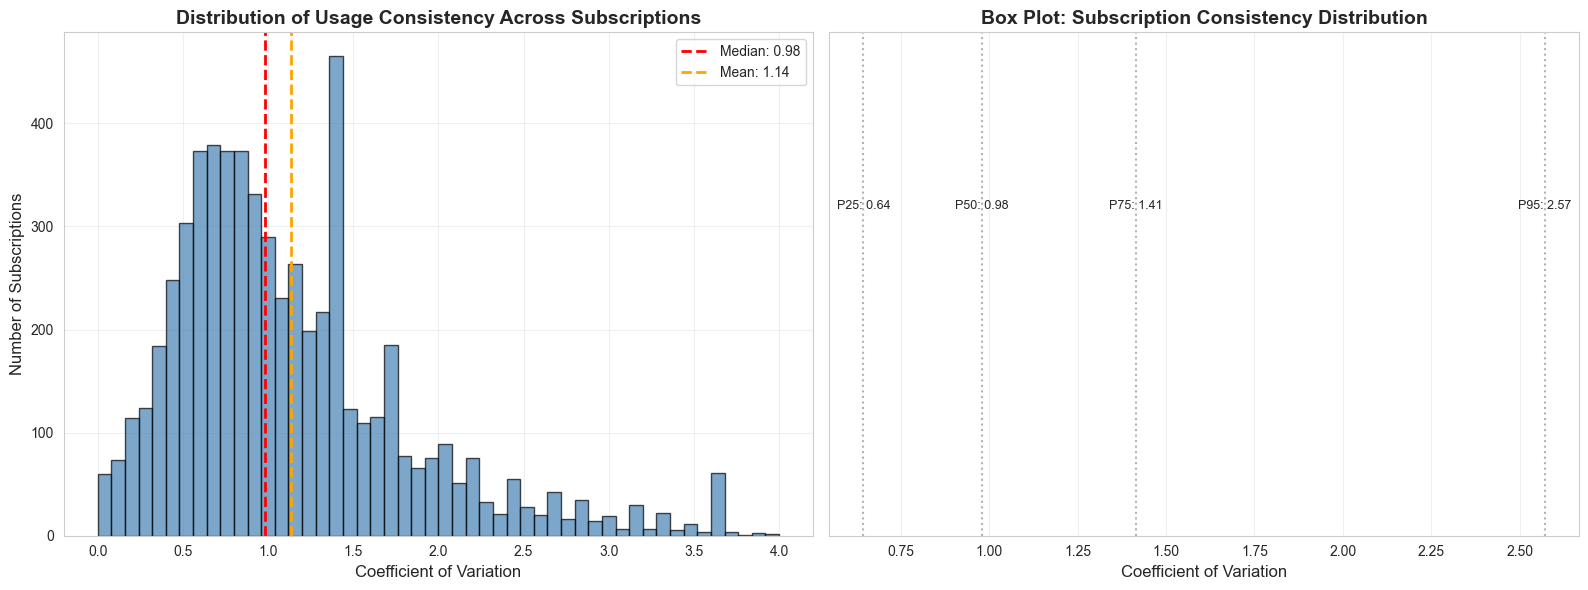

In [43]:
# Import visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Plot 1: Distribution of Coefficient of Variation
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histogram with KDE
axes[0].hist(subscription_usage['coef_var_usage'], bins=50, alpha=0.7, color='steelblue', edgecolor='black')
axes[0].axvline(subscription_usage['coef_var_usage'].median(), color='red', linestyle='--', linewidth=2, label=f'Median: {subscription_usage["coef_var_usage"].median():.2f}')
axes[0].axvline(subscription_usage['coef_var_usage'].mean(), color='orange', linestyle='--', linewidth=2, label=f'Mean: {subscription_usage["coef_var_usage"].mean():.2f}')
axes[0].set_xlabel('Coefficient of Variation', fontsize=12)
axes[0].set_ylabel('Number of Subscriptions', fontsize=12)
axes[0].set_title('Distribution of Usage Consistency Across Subscriptions', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Box plot with percentiles
box_data = subscription_usage['coef_var_usage']
bp = axes[1].boxplot([box_data], vert=False, patch_artist=True, widths=0.5)
bp['boxes'][0].set_facecolor('lightblue')
bp['boxes'][0].set_alpha(0.7)

# Add percentile annotations
percentiles = [25, 50, 75, 95]
for p in percentiles:
    val = subscription_usage['coef_var_usage'].quantile(p/100)
    axes[1].axvline(val, color='gray', linestyle=':', alpha=0.6)
    axes[1].text(val, 1.15, f'P{p}: {val:.2f}', ha='center', fontsize=9)

axes[1].set_xlabel('Coefficient of Variation', fontsize=12)
axes[1].set_title('Box Plot: Subscription Consistency Distribution', fontsize=14, fontweight='bold')
axes[1].set_yticks([])
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()


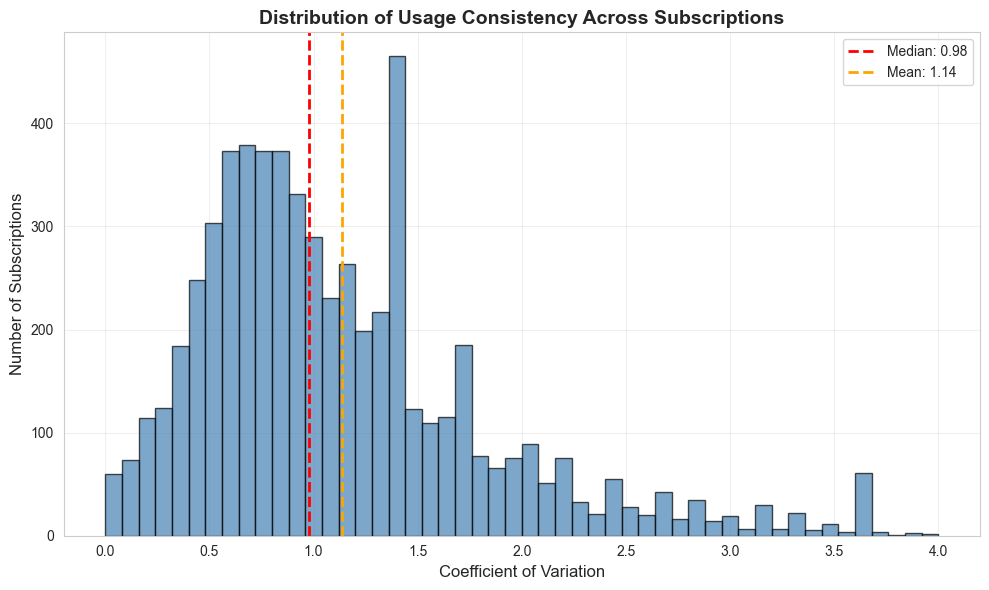

In [44]:

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)  # Adjust size as needed

# Plot: Distribution of Coefficient of Variation
plt.figure()
# Histogram with KDE
plt.hist(subscription_usage['coef_var_usage'], bins=50, alpha=0.7, color='steelblue', edgecolor='black')
plt.axvline(subscription_usage['coef_var_usage'].median(), color='red', linestyle='--', linewidth=2, label=f'Median: {subscription_usage["coef_var_usage"].median():.2f}')
plt.axvline(subscription_usage['coef_var_usage'].mean(), color='orange', linestyle='--', linewidth=2, label=f'Mean: {subscription_usage["coef_var_usage"].mean():.2f}')
plt.xlabel('Coefficient of Variation', fontsize=12)
plt.ylabel('Number of Subscriptions', fontsize=12)
plt.title('Distribution of Usage Consistency Across Subscriptions', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Answer:

Overall : moderately consistent
 - Median CV: 0.98 (moderately consistent) 

C:\Users\rober\AppData\Local\Temp\ipykernel_19912\3984384941.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(cv_by_bins, labels=[f'{int(cat.left)}-{int(cat.right)}'


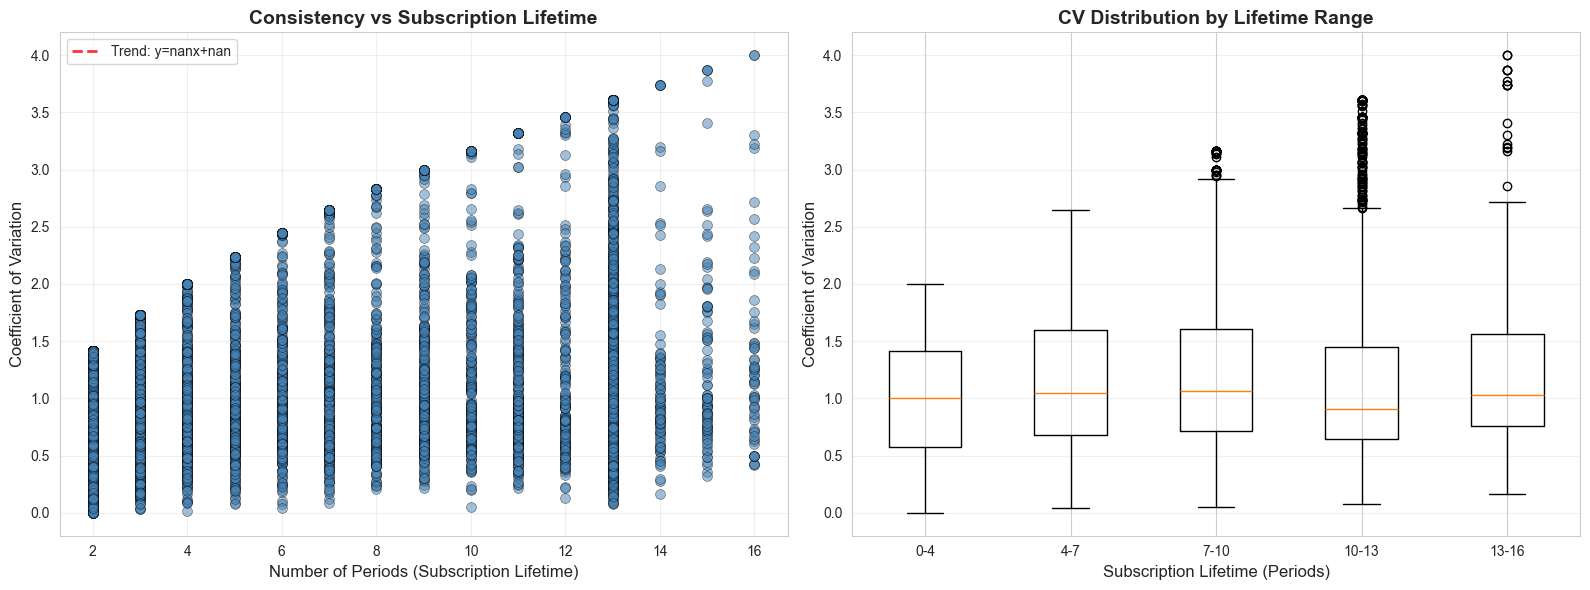

In [45]:
# Additional Analysis: Consistency vs Subscription Lifetime

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter plot: CV vs Number of Periods
axes[0].scatter(subscription_usage['count_periods'], 
                subscription_usage['coef_var_usage'], 
                alpha=0.5, s=50, color='steelblue', edgecolors='black', linewidth=0.5)

# Add trend line
z = np.polyfit(subscription_usage['count_periods'], subscription_usage['coef_var_usage'], 1)
p = np.poly1d(z)
x_trend = np.linspace(subscription_usage['count_periods'].min(), 
                      subscription_usage['count_periods'].max(), 100)
axes[0].plot(x_trend, p(x_trend), "r--", linewidth=2, alpha=0.8, label=f'Trend: y={z[0]:.3f}x+{z[1]:.3f}')

axes[0].set_xlabel('Number of Periods (Subscription Lifetime)', fontsize=12)
axes[0].set_ylabel('Coefficient of Variation', fontsize=12)
axes[0].set_title('Consistency vs Subscription Lifetime', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Boxplot: CV distribution by subscription lifetime bins
bins = pd.cut(subscription_usage['count_periods'], bins=5)
cv_by_bins = [subscription_usage[bins == bin_val]['coef_var_usage'].dropna() 
              for bin_val in bins.cat.categories]

axes[1].boxplot(cv_by_bins, labels=[f'{int(cat.left)}-{int(cat.right)}' 
                for cat in bins.cat.categories])

axes[1].set_xlabel('Subscription Lifetime (Periods)', fontsize=12)
axes[1].set_ylabel('Coefficient of Variation', fontsize=12)
axes[1].set_title('CV Distribution by Lifetime Range', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()



> With time the usage becomes more consistent.

---
## Q4: Compare the retention pattern for the most recently launched project versus the two older ones.

This is a complicated query, and analysis, but we can create a visualization that will clearly show the retention (or lack of abandonment) for each project.

To simplify:
  
- We will not filter ongoing subscriptions.
- We will limit the period to 16.
- All subscriptions are treated as the same, (also the plans)
- The size is different as well and is not taken into account.




In [46]:
print(df.head(3))

                    subscription_id  \
0  sub_b97107a1c7ef89cf28a7e83ee850   
1  sub_2353ef9e8bf55916b97ceb30194c   
2  sub_5d5605c8cf0b46116a42cedb9561   

                                  project_id__hashed  \
0  82728d5d3cf7f35b58bc318399c2c5caf7eeadcc37f359...   
1  82728d5d3cf7f35b58bc318399c2c5caf7eeadcc37f359...   
2  82728d5d3cf7f35b58bc318399c2c5caf7eeadcc37f359...   

                            plan_id       reporting_date  \
0  pln_0a3b55b9abb575b023c07e617b49  2024-02-07 00:00:00   
1  pln_0a3b55b9abb575b023c07e617b49  2024-02-08 00:00:00   
2  pln_1d3f49d61a672755efc1865c4d9a  2024-02-08 00:00:00   

  subscription_period_start subscription_period_end  \
0                2024-02-04              2024-02-07   
1                2024-01-25              2024-02-08   
2                2024-01-25              2024-02-08   

   subscription_period_number  cumulative_data_usage_megabyte  \
0                           1                        0.000000   
1                         

In [47]:
print(pro)

                                  project_id__hashed project_type  \
0  dace2786aee7632e61757b320a6fe5bff37a2e742fe558...          API   
1  82728d5d3cf7f35b58bc318399c2c5caf7eeadcc37f359...      Connect   
2  2aeca1a6c1ecf52b28b7f7646b6fb90563a417ee3e5dc3...      Connect   

   organization_name device_type  
0      People Mobile      Phones  
1         ACME Phone      Phones  
2  SmartDevices Inc.   Wearables  


In [48]:
%%sql

WITH 

-- find first period each subscription appeared
subscription_cohorts AS (
    SELECT 
        a.project_id__hashed,
        a.subscription_id,
        MIN(a.subscription_period_number) as cohort_start_period,
        MIN(a.subscription_period_start) as cohort_start_date
    FROM usage_data AS a
    GROUP BY a.project_id__hashed, a.subscription_id
),

-- find how many periods have passed since their first subscription
subs_stayers AS (
    SELECT 
        a.project_id__hashed,
        a.subscription_id,
        sc.cohort_start_date,
        a.subscription_period_number,
        a.subscription_period_number - sc.cohort_start_period + 1 as periods_since_start
    FROM usage_data AS a
    INNER JOIN subscription_cohorts sc 
        ON a.subscription_id = sc.subscription_id
        AND a.project_id__hashed = sc.project_id__hashed
),
-- count size + active users
project_cohort_retention AS (
    SELECT 
        st.project_id__hashed,
        st.periods_since_start as periods_since_start,
        COUNT(DISTINCT st.subscription_id) as active_subscribers,
        (SELECT COUNT(DISTINCT subscription_id) 
         FROM subscription_cohorts sc2 
         WHERE sc2.project_id__hashed = st.project_id__hashed) as cohort_size
    FROM subs_stayers st
    GROUP BY st.project_id__hashed, st.periods_since_start
),

-- compute retention % +  show labels 
retention_with_project_info AS (
    SELECT 
        p.organization_name,
        p.project_type,
        p.device_type,
        pcr.periods_since_start,
        pcr.active_subscribers,
        pcr.cohort_size,
        ROUND(pcr.active_subscribers * 100 / pcr.cohort_size, 2) as retention_rate_pct,
        (SELECT MIN(cohort_start_date) 
         FROM subscription_cohorts sc3 
         WHERE sc3.project_id__hashed = pcr.project_id__hashed) as first_subscription_date,
        CASE 
        
        -- this is not scalable, but is easier to read
            WHEN (SELECT MIN(cohort_start_date) 
                  FROM subscription_cohorts sc3 
                  WHERE sc3.project_id__hashed = pcr.project_id__hashed) = (
                SELECT MAX(first_sub) FROM (
                    SELECT MIN(cohort_start_date) as first_sub 
                    FROM subscription_cohorts 
                    GROUP BY project_id__hashed
                )
            ) 
            THEN 'Most Recent' 
            ELSE 'Older' 
        END as project_age_label
    FROM project_cohort_retention pcr
    INNER JOIN projects p ON pcr.project_id__hashed = p.project_id__hashed
    WHERE pcr.periods_since_start <= 16
)

SELECT 
    organization_name,
    project_type,
    device_type,
    project_age_label,
    periods_since_start,
    active_subscribers,
    cohort_size,
    retention_rate_pct,
    first_subscription_date
FROM retention_with_project_info
ORDER BY 
    first_subscription_date DESC,
    periods_since_start
    limit 5;


,organization_name,project_type,device_type,project_age_label,periods_since_start,active_subscribers,cohort_size,retention_rate_pct,first_subscription_date
0,People Mobile,API,Phones,Most Recent,1,734,734,100.00,2025-04-01
1,People Mobile,API,Phones,Most Recent,2,89,734,12.13,2025-04-01
2,SmartDevices Inc.,Connect,Wearables,Older,1,986,986,100.00,2025-03-04
3,SmartDevices Inc.,Connect,Wearables,Older,2,366,986,37.12,2025-03-04
4,SmartDevices Inc.,Connect,Wearables,Older,3,121,986,12.27,2025-03-04


In [49]:
df_true_retention = conn.execute("""
WITH 

subscription_cohorts AS (
    SELECT 
        a.project_id__hashed,
        a.subscription_id,
        MIN(a.subscription_period_number) as cohort_start_period,
        MIN(a.subscription_period_start) as cohort_start_date
    FROM usage_data AS a
    GROUP BY a.project_id__hashed, a.subscription_id
),

subs_stayers AS (
    SELECT 
        a.project_id__hashed,
        a.subscription_id,
        sc.cohort_start_date,
        a.subscription_period_number,
        a.subscription_period_number - sc.cohort_start_period + 1 as periods_since_start
    FROM usage_data AS a
    INNER JOIN subscription_cohorts sc 
        ON a.subscription_id = sc.subscription_id
        AND a.project_id__hashed = sc.project_id__hashed
),

project_cohort_retention AS (
    SELECT 
        st.project_id__hashed,
        st.periods_since_start as periods_since_start,
        COUNT(DISTINCT st.subscription_id) as active_subscribers,
        (SELECT COUNT(DISTINCT subscription_id) 
         FROM subscription_cohorts sc2 
         WHERE sc2.project_id__hashed = st.project_id__hashed) as cohort_size
    FROM subs_stayers st
    GROUP BY st.project_id__hashed, st.periods_since_start
),

retention_with_project_info AS (
    SELECT 
        p.organization_name,
        p.project_type,
        p.device_type,
        pcr.periods_since_start,
        pcr.active_subscribers,
        pcr.cohort_size,
        ROUND(pcr.active_subscribers * 100 / pcr.cohort_size, 2) as retention_rate_pct,
        (SELECT MIN(cohort_start_date) 
         FROM subscription_cohorts sc3 
         WHERE sc3.project_id__hashed = pcr.project_id__hashed) as first_subscription_date,
        CASE 
            WHEN (SELECT MIN(cohort_start_date) 
                  FROM subscription_cohorts sc3 
                  WHERE sc3.project_id__hashed = pcr.project_id__hashed) = (
                SELECT MAX(first_sub) FROM (
                    SELECT MIN(cohort_start_date) as first_sub 
                    FROM subscription_cohorts 
                    GROUP BY project_id__hashed
                )
            ) 
            THEN 'Most Recent' 
            ELSE 'Older' 
        END as project_age_label
    FROM project_cohort_retention pcr
    INNER JOIN projects p ON pcr.project_id__hashed = p.project_id__hashed
    WHERE pcr.periods_since_start <= 16
)

SELECT 
    organization_name,
    project_type,
    device_type,
    project_age_label,
    periods_since_start,
    active_subscribers,
    cohort_size,
    retention_rate_pct,
    first_subscription_date
FROM retention_with_project_info
ORDER BY 
    first_subscription_date DESC,
    periods_since_start
""").df()

df.head(2)

,subscription_id,project_id__hashed,plan_id,reporting_date,subscription_period_start,subscription_period_end,subscription_period_number,cumulative_data_usage_megabyte,cumulative_voice_usage_minutes,cumulative_sms_usage,number_of_addons_activated
0,sub_b97107a1c7ef89cf28a7e83ee850,82728d5d3cf7f35b58bc318399c2c5caf7eeadcc37f359...,pln_0a3b55b9abb575b023c07e617b49,2024-02-07 00:00:00,2024-02-04,2024-02-07,1,0.000000,0.0,0.0,0
1,sub_2353ef9e8bf55916b97ceb30194c,82728d5d3cf7f35b58bc318399c2c5caf7eeadcc37f359...,pln_0a3b55b9abb575b023c07e617b49,2024-02-08 00:00:00,2024-01-25,2024-02-08,1,56.660992,1.0,1.0,0


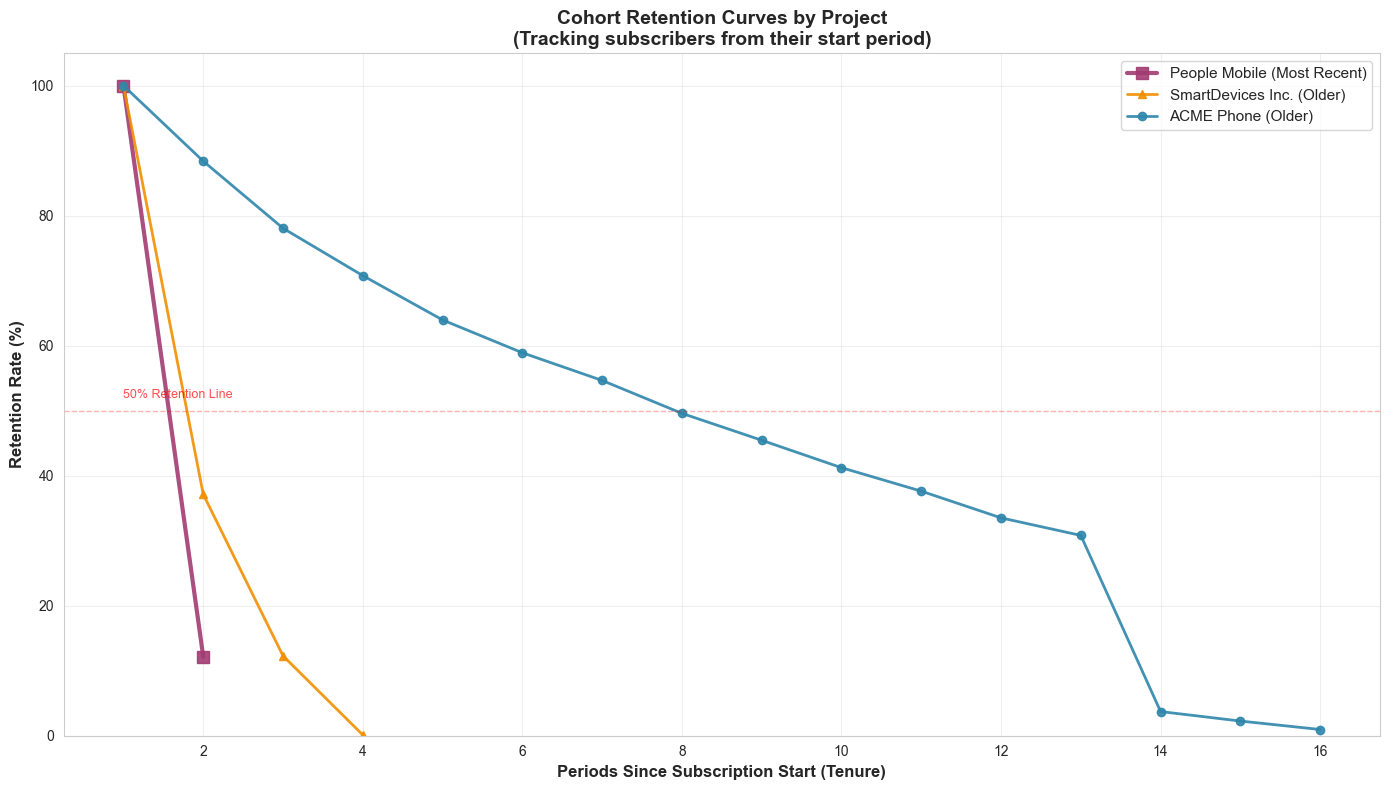

In [50]:


# Create the retention curve visualization
plt.figure(figsize=(14, 8))

# Define colors for each project (most recent gets distinctive color)
colors = {'ACME Phone': '#2E86AB', 'People Mobile': '#A23B72', 'SmartDevices Inc.': '#F18F01'}
markers = {'ACME Phone': 'o', 'People Mobile': 's', 'SmartDevices Inc.': '^'}

for org in df_true_retention['organization_name'].unique():
    org_data = df_true_retention[df_true_retention['organization_name'] == org]
    project_label = org_data['project_age_label'].iloc[0]
    
    # Make most recent project line bolder
    linewidth = 3 if project_label == 'Most Recent' else 2
    markersize = 8 if project_label == 'Most Recent' else 6
    
    label = f"{org} ({project_label})"
    plt.plot(org_data['periods_since_start'], 
             org_data['retention_rate_pct'], 
             marker=markers.get(org, 'o'),
             label=label, 
             linewidth=linewidth,
             markersize=markersize,
             color=colors.get(org),
             alpha=0.9)

plt.xlabel('Periods Since Subscription Start (Tenure)', fontsize=12, fontweight='bold')
plt.ylabel('Retention Rate (%)', fontsize=12, fontweight='bold')
plt.title('Cohort Retention Curves by Project\n(Tracking subscribers from their start period)', 
          fontsize=14, fontweight='bold')
plt.legend(loc='best', fontsize=11)
plt.grid(True, alpha=0.3)
plt.ylim(0, 105)

# Add annotations
plt.axhline(y=50, color='red', linestyle='--', alpha=0.3, linewidth=1)
plt.text(1, 52, '50% Retention Line', fontsize=9, color='red', alpha=0.7)

plt.tight_layout()
plt.show()



Clearly ACME Phone is the best performer.


Questions : 

- What is making the users churn?
- Is there a new adversary ? 
- Do we have an increase in complains? 
- Do we have decrease in usage that could point out technical issues?
- What is the price comparison between this and previous plans? 
- Is the speed of data the same? 
- does the service has more outages?
- Do customer support is the same? 
- are there promotions that helped the other projects to retain more customers?


----
# Lets ADD Money to the study!

In [51]:
df.head(2)

,subscription_id,project_id__hashed,plan_id,reporting_date,subscription_period_start,subscription_period_end,subscription_period_number,cumulative_data_usage_megabyte,cumulative_voice_usage_minutes,cumulative_sms_usage,number_of_addons_activated
0,sub_b97107a1c7ef89cf28a7e83ee850,82728d5d3cf7f35b58bc318399c2c5caf7eeadcc37f359...,pln_0a3b55b9abb575b023c07e617b49,2024-02-07 00:00:00,2024-02-04,2024-02-07,1,0.000000,0.0,0.0,0
1,sub_2353ef9e8bf55916b97ceb30194c,82728d5d3cf7f35b58bc318399c2c5caf7eeadcc37f359...,pln_0a3b55b9abb575b023c07e617b49,2024-02-08 00:00:00,2024-01-25,2024-02-08,1,56.660992,1.0,1.0,0


In [52]:
plan.head(2)

,plan_id,project_id__hashed,plan_created_at,event_type,event_timestamp,plan_name,network_provider_id,price_currency,plan_price_amount_local,data_allowance_mb,is_unlimited_data,voice_allowance_seconds,is_unlimited_voice,sms_allowance,is_unlimited_sms,validity_value,validity_unit,_valid_from,_valid_to,_is_current_state
0,pln_b2a155624e05108d1a5b6b90f567,82728d5d3cf7f35b58bc318399c2c5caf7eeadcc37f359...,2023-12-29 18:43:12,plan.updated,2023-12-29 18:44:37.573698,Unlimited Data Plan,p4,USD,70.0,NaN,True,NaN,True,NaN,True,30,day,2023-12-29 18:44:37.573698,2023-12-29 18:44:37.846803,False
1,pln_b2a155624e05108d1a5b6b90f567,82728d5d3cf7f35b58bc318399c2c5caf7eeadcc37f359...,2023-12-29 18:43:12,plan.archived,2024-01-21 15:48:13.444971,Unlimited Data Plan,p4,USD,70.0,NaN,True,NaN,True,NaN,True,30,day,2024-01-21 15:48:13.444971,NaN,True


#### First we need to find the price for each subscription

For this we get the cost of each plan at the time is reported (the reporting period has to match the validiy of the plan!)

In [53]:

%%sql

-- Create a table for prices per plan by each reporting date
with base as (
  
  select distinct project_id__hashed,	plan_id,	reporting_date
  from usage_data
)

,final as (
select


a.*,
b._valid_from,
b._valid_to,
b.plan_price_amount_local


from base as a
left join plan_events as b
on a.project_id__hashed = b.project_id__hashed
and a.plan_id = b.plan_id
and b._valid_from<= a.reporting_date 
and (b._valid_to is null or b._valid_to >= a.reporting_date )
)


select 
-- we should have one line per project plan and report date
project_id__hashed,	plan_id,	reporting_date	,count(*) as counts

from final

group by 1,2,3 order by counts desc

limit 3

,project_id__hashed,plan_id,reporting_date,counts
0,82728d5d3cf7f35b58bc318399c2c5caf7eeadcc37f359...,pln_af7b4a30086929d37e7f4eb3daed,2024-02-28,1
1,82728d5d3cf7f35b58bc318399c2c5caf7eeadcc37f359...,pln_0a3b55b9abb575b023c07e617b49,2024-03-09,1
2,82728d5d3cf7f35b58bc318399c2c5caf7eeadcc37f359...,pln_af7b4a30086929d37e7f4eb3daed,2024-03-14,1


> OK! it works, each plan has 1 price; so lets put it in a table

In [54]:

%%sql
CREATE OR REPLACE TABLE plan_cost AS 

with base as (
  
  select distinct project_id__hashed,	plan_id,	reporting_date
  from usage_data
)

,final as (
select


a.*,
b.plan_name,
b._valid_from,
b._valid_to,
b.plan_price_amount_local


from base as a
left join plan_events as b
on a.project_id__hashed = b.project_id__hashed
and a.plan_id = b.plan_id
and b._valid_from<= a.reporting_date 
and (b._valid_to is null or b._valid_to >= a.reporting_date )
)


select 

*

from final;


select * from plan_cost limit 3

,project_id__hashed,plan_id,reporting_date,plan_name,_valid_from,_valid_to,plan_price_amount_local
0,82728d5d3cf7f35b58bc318399c2c5caf7eeadcc37f359...,pln_0a3b55b9abb575b023c07e617b49,2024-02-07,Easy Plan,2024-01-24 18:25:07.645118,2024-08-01 17:22:46.678886,30.0
1,82728d5d3cf7f35b58bc318399c2c5caf7eeadcc37f359...,pln_0a3b55b9abb575b023c07e617b49,2024-02-08,Easy Plan,2024-01-24 18:25:07.645118,2024-08-01 17:22:46.678886,30.0
2,82728d5d3cf7f35b58bc318399c2c5caf7eeadcc37f359...,pln_0a3b55b9abb575b023c07e617b49,2024-02-24,Easy Plan,2024-01-24 18:25:07.645118,2024-08-01 17:22:46.678886,30.0


In [55]:
%%sql

select 

b.organization_name,
c.plan_name,

STRFTIME(a.reporting_date, '%Y-%m') as reporting_month,
c.plan_price_amount_local,
SUM(a.cumulative_data_usage_megabyte) as cumulative_data_usage_megabyte,
SUM(a.cumulative_voice_usage_minutes) as cumulative_voice_usage_minutes,
SUM(a.cumulative_sms_usage) as cumulative_sms_usage

from usage_data as a
left join projects as b
on a.project_id__hashed = b.project_id__hashed

left join plan_cost as c
on  a.project_id__hashed = c.project_id__hashed
and a.plan_id = c.plan_id
and a.reporting_date = c.reporting_date

group by 1,2,3,4 , order by 1,2,3

,organization_name,plan_name,reporting_month,plan_price_amount_local,cumulative_data_usage_megabyte,cumulative_voice_usage_minutes,cumulative_sms_usage
0,ACME Phone,Easy Plan,2024-02,30.0,3.781843e+04,11114.0,15555.0
1,ACME Phone,Easy Plan,2024-03,30.0,1.071480e+05,56341.0,98449.0
2,ACME Phone,Easy Plan,2024-04,30.0,2.795052e+05,88942.0,113410.0
3,ACME Phone,Easy Plan,2024-05,30.0,1.623359e+06,920945.0,924327.0
4,ACME Phone,Easy Plan,2024-06,30.0,1.123537e+06,878299.0,1074078.0
...,...,...,...,...,...,...,...
64,SmartDevices Inc.,Basic Plan,2025-06,20.0,1.988041e+05,4.0,544.0
65,SmartDevices Inc.,Unlimited Plan,2025-03,40.0,1.413444e+04,14.0,53.0
66,SmartDevices Inc.,Unlimited Plan,2025-04,40.0,5.310899e+05,26.0,861.0
67,SmartDevices Inc.,Unlimited Plan,2025-05,40.0,1.252360e+06,60.0,4388.0


In [56]:
%%sql

select 

b.organization_name,
c.plan_name,

SUM(c.plan_price_amount_local) AS price_bill,
SUM(a.cumulative_data_usage_megabyte) as cumulative_data_usage_megabyte,
SUM(a.cumulative_data_usage_megabyte)/SUM(c.plan_price_amount_local) AS mb_per_usd,
SUM(c.plan_price_amount_local)/SUM(a.cumulative_data_usage_megabyte) AS usd_per_mb,

SUM(a.cumulative_voice_usage_minutes) as cumulative_voice_usage_minutes,
SUM(a.cumulative_sms_usage) as cumulative_sms_usage

from usage_data as a
left join projects as b
on a.project_id__hashed = b.project_id__hashed

left join plan_cost as c
on  a.project_id__hashed = c.project_id__hashed
and a.plan_id = c.plan_id
and a.reporting_date = c.reporting_date

where STRFTIME(a.reporting_date, '%Y') = 2025

group by 1,2 , order by 3 desc

,organization_name,plan_name,price_bill,cumulative_data_usage_megabyte,mb_per_usd,usd_per_mb,cumulative_voice_usage_minutes,cumulative_sms_usage
0,ACME Phone,Easy Plan,499980.0,5.294520e+06,10.589464,0.094433,4057142.00,4663006.0
1,ACME Phone,Unlimited Data Plan,99120.0,8.200044e+06,82.728450,0.012088,450161.00,422008.0
2,ACME Phone,Plus Plan,55980.0,2.127603e+06,38.006478,0.026311,344910.00,375643.0
3,SmartDevices Inc.,Unlimited Plan,40560.0,3.137163e+06,77.346239,0.012929,195.00,6970.0
4,People Mobile,Ultra Unlimited,21525.0,1.643194e+07,763.388659,0.001310,277906.19,184625.0
5,SmartDevices Inc.,Basic Plan,9200.0,5.838026e+05,63.456807,0.015759,21.00,1998.0
6,People Mobile,5GB,2070.0,2.849063e+05,137.635915,0.007266,30252.65,11800.0
7,People Mobile,5GB Plan,2.0,1.867571e+01,9.337856,0.107091,0.07,0.0
8,People Mobile,No Allowances Plan,0.0,2.561443e+05,inf,0.000000,4354.49,1999.0


> Certainly Easy plan is the most used and one of the most cheap offers, people get 10mb per dollar, thats way less than Unlimited plan! 

In [57]:
df = conn.execute("""

select 

b.organization_name,
c.plan_name,

STRFTIME(a.reporting_date, '%Y-%m') as reporting_month,
c.plan_price_amount_local,
SUM(a.cumulative_data_usage_megabyte) as cumulative_data_usage_megabyte,
SUM(a.cumulative_voice_usage_minutes) as cumulative_voice_usage_minutes,
SUM(a.cumulative_sms_usage) as cumulative_sms_usage

from usage_data as a
left join projects as b
on a.project_id__hashed = b.project_id__hashed

left join plan_cost as c
on  a.project_id__hashed = c.project_id__hashed
and a.plan_id = c.plan_id
and a.reporting_date = c.reporting_date

group by 1,2,3,4 , order by 1,2,3""").df()


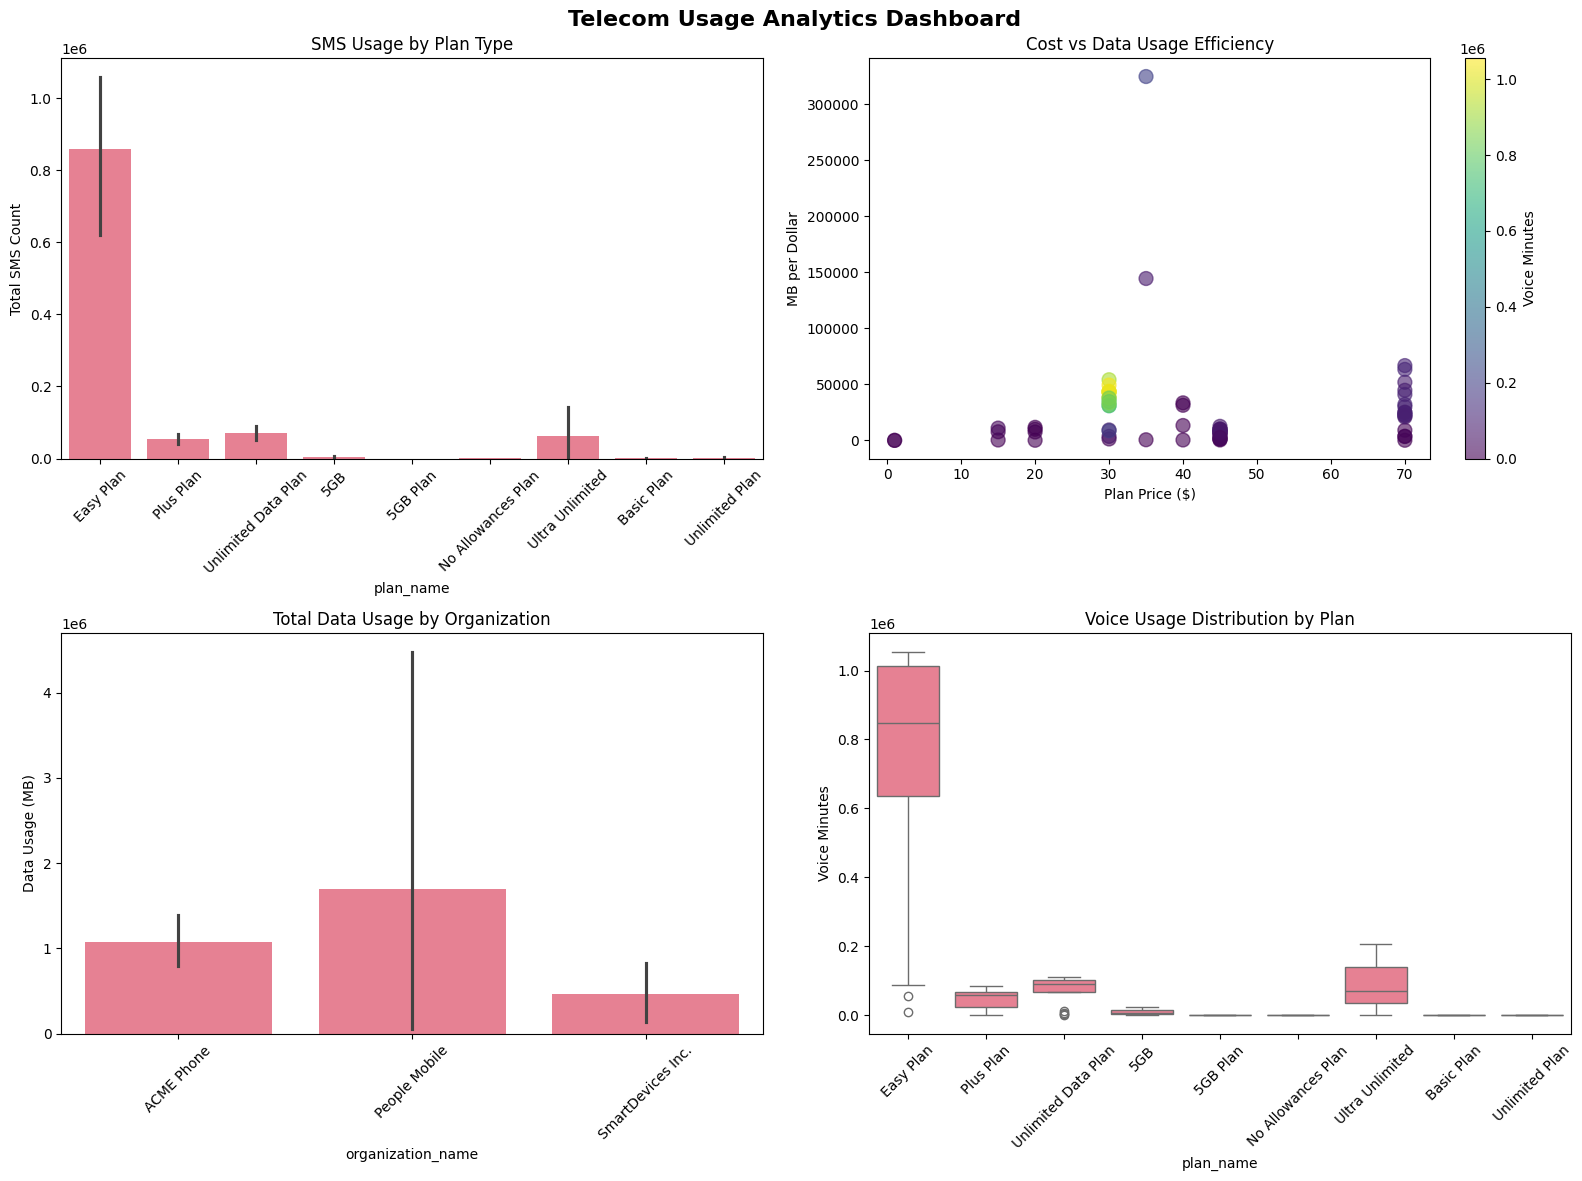

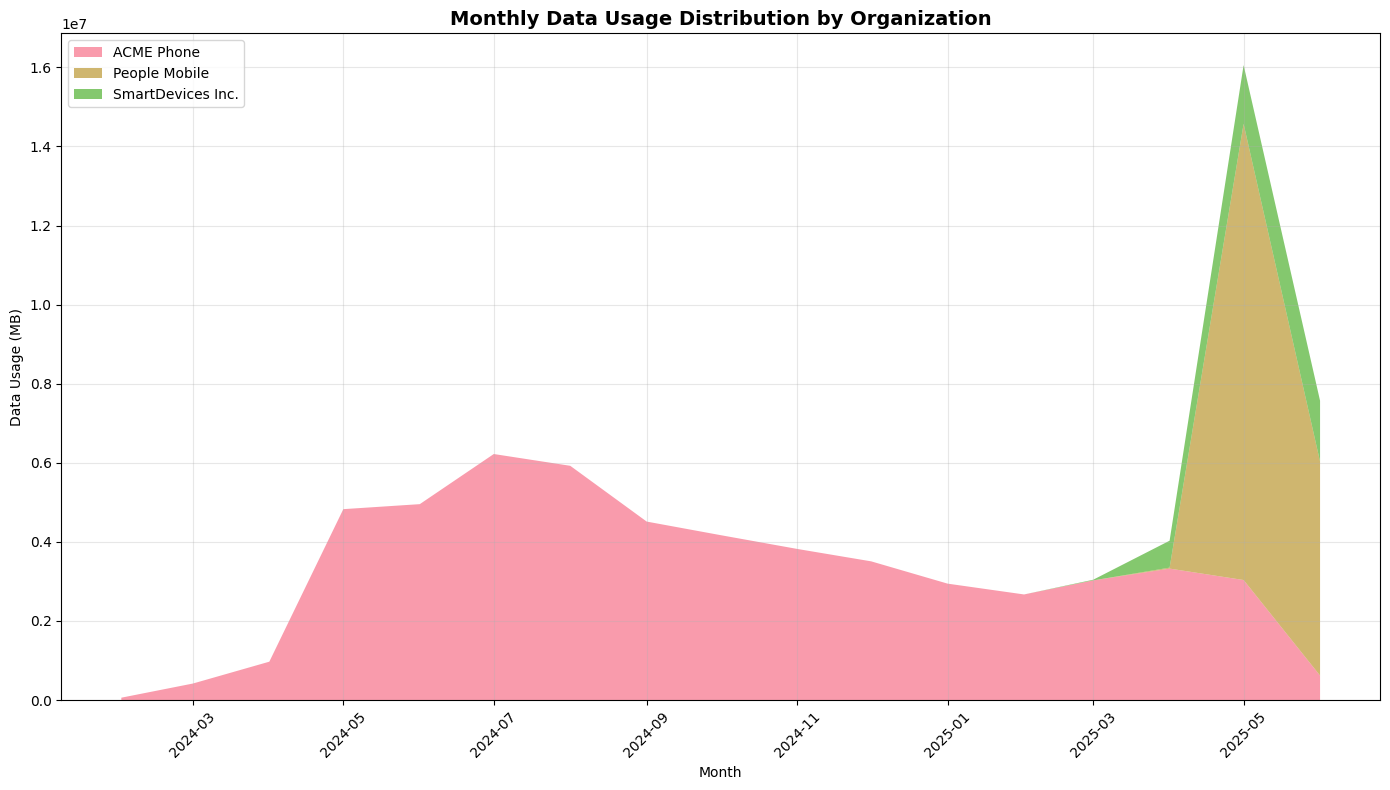

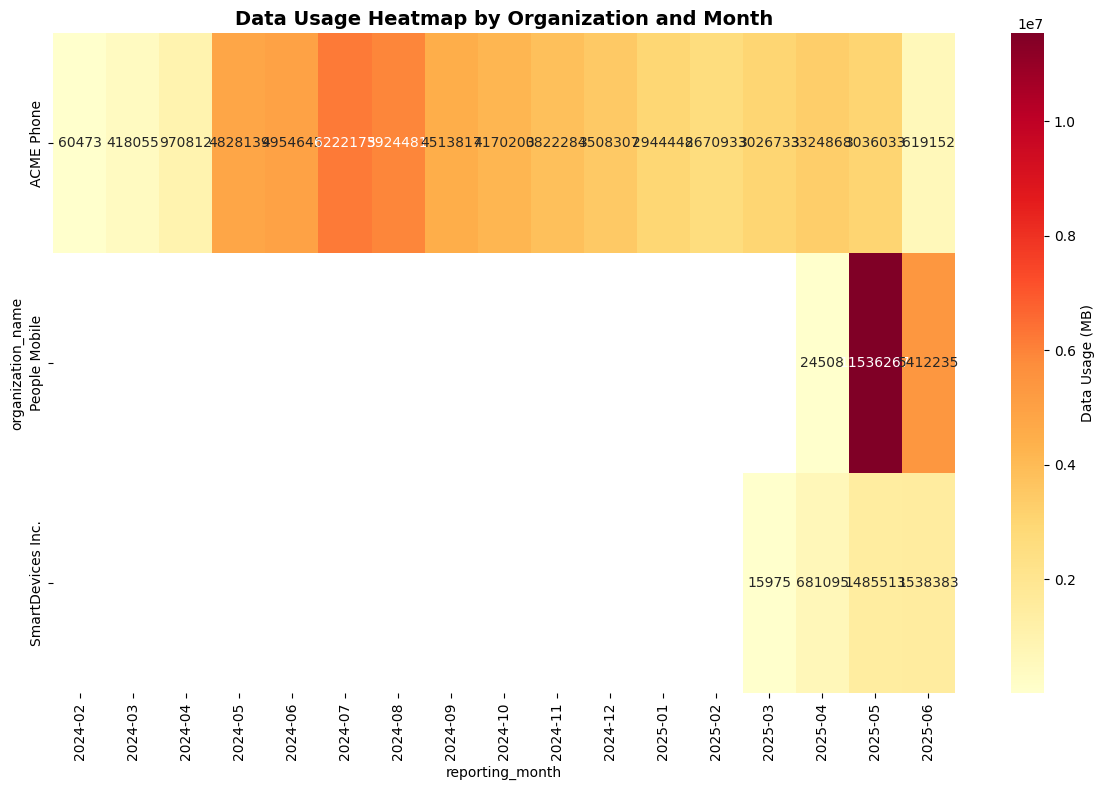

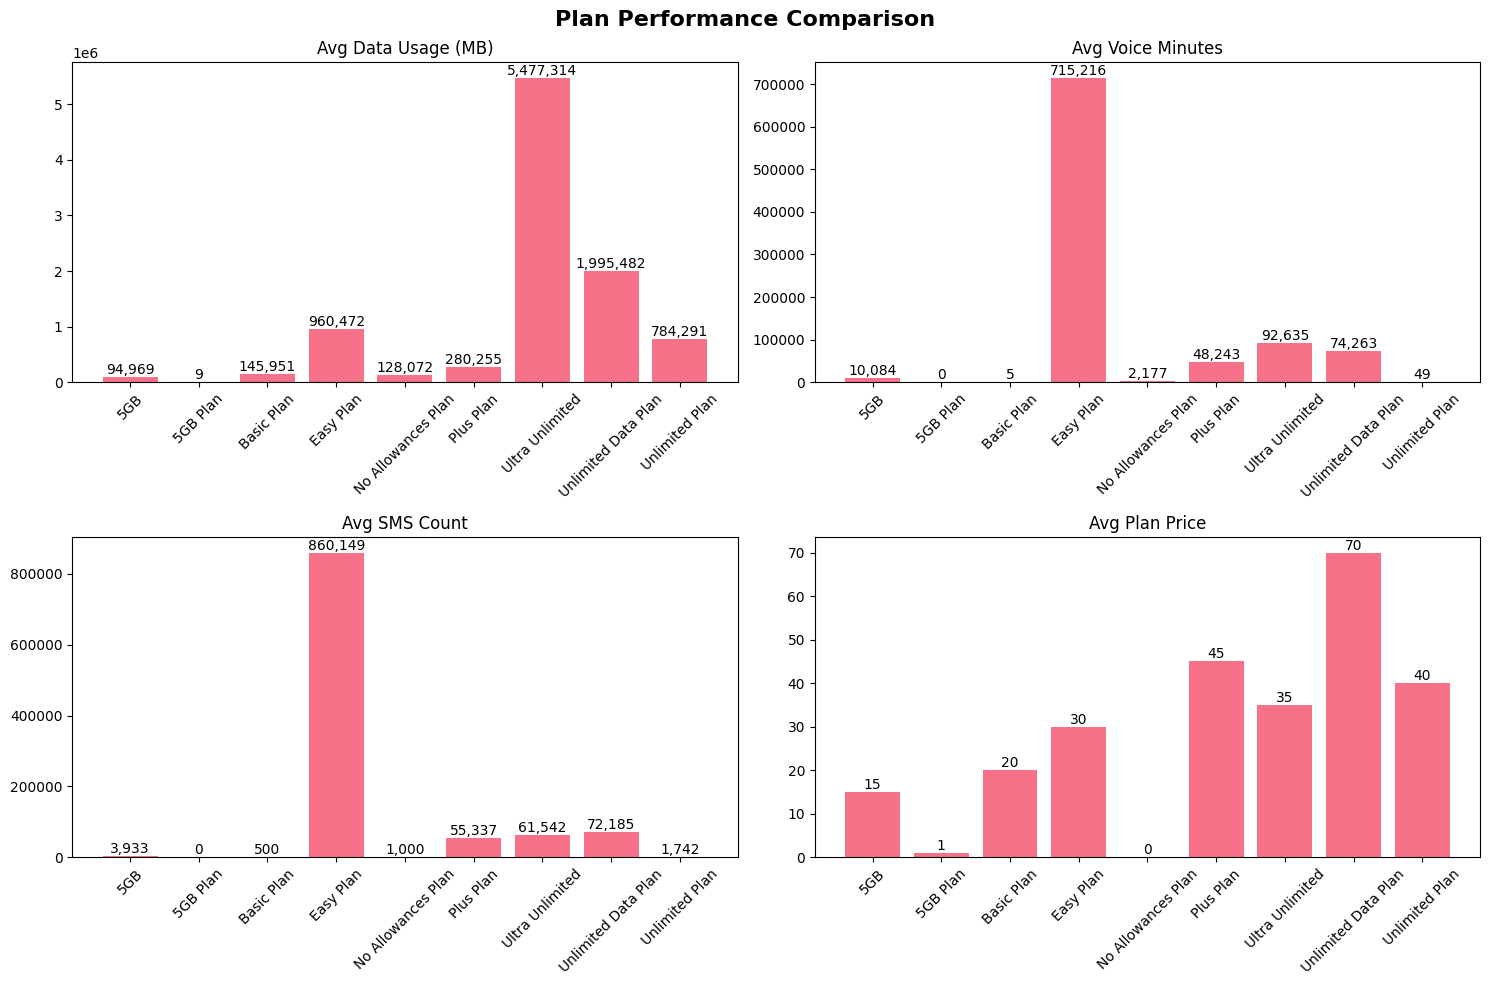

In [58]:
plt.style.use('default')
sns.set_palette("husl")

# Convert reporting_month to datetime for better plotting
df['reporting_month'] = pd.to_datetime(df['reporting_month'] + '-01')

# 1. MULTI-PLOT DASHBOARD (2x2 layout but now with different charts)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Telecom Usage Analytics Dashboard', fontsize=16, fontweight='bold')

# 1.1 SMS Usage by Plan
sns.barplot(data=df, x='plan_name', y='cumulative_sms_usage', ax=axes[0,0])
axes[0,0].set_title('SMS Usage by Plan Type')
axes[0,0].set_ylabel('Total SMS Count')
axes[0,0].tick_params(axis='x', rotation=45)

# 1.2 Monthly Cost vs Usage Efficiency
scatter = axes[0,1].scatter(df['plan_price_amount_local'], 
                           df['cumulative_data_usage_megabyte'] / df['plan_price_amount_local'],
                           c=df['cumulative_voice_usage_minutes'], 
                           s=100, alpha=0.6, cmap='viridis')
axes[0,1].set_title('Cost vs Data Usage Efficiency')
axes[0,1].set_xlabel('Plan Price ($)')
axes[0,1].set_ylabel('MB per Dollar')
plt.colorbar(scatter, ax=axes[0,1], label='Voice Minutes')

# 1.3 Data Usage by Organization (Bar plot)
sns.barplot(data=df, x='organization_name', y='cumulative_data_usage_megabyte', ax=axes[1,0])
axes[1,0].set_title('Total Data Usage by Organization')
axes[1,0].set_ylabel('Data Usage (MB)')
axes[1,0].tick_params(axis='x', rotation=45)

# 1.4 Voice Usage by Plan
sns.boxplot(data=df, x='plan_name', y='cumulative_voice_usage_minutes', ax=axes[1,1])
axes[1,1].set_title('Voice Usage Distribution by Plan')
axes[1,1].set_ylabel('Voice Minutes')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# 2. STACKED AREA CHART - Monthly Usage Comparison
plt.figure(figsize=(14, 8))

# Pivot data for stacked area chart
pivot_data = df.pivot_table(
    index='reporting_month', 
    columns='organization_name', 
    values='cumulative_data_usage_megabyte', 
    aggfunc='sum'
).fillna(0)

plt.stackplot(pivot_data.index, 
              [pivot_data[col] for col in pivot_data.columns],
              labels=pivot_data.columns,
              alpha=0.7)

plt.title('Monthly Data Usage Distribution by Organization', fontsize=14, fontweight='bold')
plt.ylabel('Data Usage (MB)')
plt.xlabel('Month')
plt.legend(loc='upper left')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 3. Usage Patterns
plt.figure(figsize=(12, 8))

# Create a pivot table for the heatmap
heatmap_data = df.pivot_table(
    index='organization_name',
    columns=df['reporting_month'].dt.strftime('%Y-%m'),
    values='cumulative_data_usage_megabyte',
    aggfunc='sum'
)

sns.heatmap(heatmap_data, 
            annot=True, 
            fmt='.0f', 
            cmap='YlOrRd',
            cbar_kws={'label': 'Data Usage (MB)'})
plt.title('Data Usage Heatmap by Organization and Month', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 4. PLAN COMPARISON - Side by Side
plan_comparison = df.groupby('plan_name').agg({
    'cumulative_data_usage_megabyte': 'mean',
    'cumulative_voice_usage_minutes': 'mean',
    'cumulative_sms_usage': 'mean',
    'plan_price_amount_local': 'mean'
}).reset_index()

fig, ax = plt.subplots(2, 2, figsize=(15, 10))

# Normalize for better comparison
metrics = ['cumulative_data_usage_megabyte', 'cumulative_voice_usage_minutes', 
           'cumulative_sms_usage', 'plan_price_amount_local']
titles = ['Avg Data Usage (MB)', 'Avg Voice Minutes', 'Avg SMS Count', 'Avg Plan Price']

for i, (metric, title) in enumerate(zip(metrics, titles)):
    row, col = i // 2, i % 2
    bars = ax[row, col].bar(plan_comparison['plan_name'], plan_comparison[metric])
    ax[row, col].set_title(title)
    ax[row, col].tick_params(axis='x', rotation=45)
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax[row, col].text(bar.get_x() + bar.get_width()/2., height,
                         f'{height:,.0f}',
                         ha='center', va='bottom')

plt.suptitle('Plan Performance Comparison', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [59]:
#Check

# m1 = cost.project_id__hashed == '82728d5d3cf7f35b58bc318399c2c5caf7eeadcc37f3597cb2817a9b5a87bbf3'
# m2 = cost.plan_id == 'pln_af7b4a30086929d37e7f4eb3daed'
# m3 = cost.date== '2024-04-07'
# cost[m1 & m2 & m3]

In [60]:
# cost_df = conn.execute("SELECT * FROM plan_cost").df()
# cost_df.head(3)


---
---
---
# Sandbox

In [61]:
%%sql

# example of a subscription with multiple plans
select 
* 
from projects
limit 5;

,project_id__hashed,project_type,organization_name,device_type
0,dace2786aee7632e61757b320a6fe5bff37a2e742fe558...,API,People Mobile,Phones
1,82728d5d3cf7f35b58bc318399c2c5caf7eeadcc37f359...,Connect,ACME Phone,Phones
2,2aeca1a6c1ecf52b28b7f7646b6fb90563a417ee3e5dc3...,Connect,SmartDevices Inc.,Wearables


In [62]:
%%sql

# example of a subscription with multiple plans
select 
* 
from plan_events
limit 3;

,plan_id,project_id__hashed,plan_created_at,event_type,event_timestamp,plan_name,network_provider_id,price_currency,plan_price_amount_local,data_allowance_mb,is_unlimited_data,voice_allowance_seconds,is_unlimited_voice,sms_allowance,is_unlimited_sms,validity_value,validity_unit,_valid_from,_valid_to,_is_current_state
0,pln_b2a155624e05108d1a5b6b90f567,82728d5d3cf7f35b58bc318399c2c5caf7eeadcc37f359...,2023-12-29 18:43:12,plan.updated,2023-12-29 18:44:37.573698,Unlimited Data Plan,p4,USD,70.0,NaN,True,NaN,True,NaN,True,30,day,2023-12-29 18:44:37.573698,2023-12-29 18:44:37.846803,False
1,pln_b2a155624e05108d1a5b6b90f567,82728d5d3cf7f35b58bc318399c2c5caf7eeadcc37f359...,2023-12-29 18:43:12,plan.archived,2024-01-21 15:48:13.444971,Unlimited Data Plan,p4,USD,70.0,NaN,True,NaN,True,NaN,True,30,day,2024-01-21 15:48:13.444971,NaT,True
2,pln_b2a155624e05108d1a5b6b90f567,82728d5d3cf7f35b58bc318399c2c5caf7eeadcc37f359...,2023-12-29 18:43:12,plan.updated,2024-01-21 15:48:12.953812,Unlimited Data Plan,p4,USD,70.0,NaN,True,NaN,True,NaN,True,30,day,2024-01-21 15:48:12.953812,2024-01-21 15:48:13.444971,False


In [63]:
%%sql

# example of a subscription with multiple plans
select 
* 
from usage_data
limit 5

,subscription_id,project_id__hashed,plan_id,reporting_date,subscription_period_start,subscription_period_end,subscription_period_number,cumulative_data_usage_megabyte,cumulative_voice_usage_minutes,cumulative_sms_usage,number_of_addons_activated
0,sub_b97107a1c7ef89cf28a7e83ee850,82728d5d3cf7f35b58bc318399c2c5caf7eeadcc37f359...,pln_0a3b55b9abb575b023c07e617b49,2024-02-07,2024-02-04,2024-02-07,1,0.000000,0.0,0.0,0
1,sub_2353ef9e8bf55916b97ceb30194c,82728d5d3cf7f35b58bc318399c2c5caf7eeadcc37f359...,pln_0a3b55b9abb575b023c07e617b49,2024-02-08,2024-01-25,2024-02-08,1,56.660992,1.0,1.0,0
2,sub_5d5605c8cf0b46116a42cedb9561,82728d5d3cf7f35b58bc318399c2c5caf7eeadcc37f359...,pln_1d3f49d61a672755efc1865c4d9a,2024-02-08,2024-01-25,2024-02-08,1,160.659456,0.0,1.0,0
3,sub_8e114d3a638d12ca1526a3fbedd6,82728d5d3cf7f35b58bc318399c2c5caf7eeadcc37f359...,pln_0a3b55b9abb575b023c07e617b49,2024-02-08,2024-01-28,2024-02-08,1,156.870656,93.0,198.0,0
4,sub_16059484727214a6b903fa16d0fe,82728d5d3cf7f35b58bc318399c2c5caf7eeadcc37f359...,pln_0a3b55b9abb575b023c07e617b49,2024-02-10,2024-02-09,2024-02-10,1,0.000000,0.0,0.0,0


In [64]:
%%sql

# example of a subscription with multiple plans
select 
* 
from plan_events
limit 3

,plan_id,project_id__hashed,plan_created_at,event_type,event_timestamp,plan_name,network_provider_id,price_currency,plan_price_amount_local,data_allowance_mb,is_unlimited_data,voice_allowance_seconds,is_unlimited_voice,sms_allowance,is_unlimited_sms,validity_value,validity_unit,_valid_from,_valid_to,_is_current_state
0,pln_b2a155624e05108d1a5b6b90f567,82728d5d3cf7f35b58bc318399c2c5caf7eeadcc37f359...,2023-12-29 18:43:12,plan.updated,2023-12-29 18:44:37.573698,Unlimited Data Plan,p4,USD,70.0,NaN,True,NaN,True,NaN,True,30,day,2023-12-29 18:44:37.573698,2023-12-29 18:44:37.846803,False
1,pln_b2a155624e05108d1a5b6b90f567,82728d5d3cf7f35b58bc318399c2c5caf7eeadcc37f359...,2023-12-29 18:43:12,plan.archived,2024-01-21 15:48:13.444971,Unlimited Data Plan,p4,USD,70.0,NaN,True,NaN,True,NaN,True,30,day,2024-01-21 15:48:13.444971,NaT,True
2,pln_b2a155624e05108d1a5b6b90f567,82728d5d3cf7f35b58bc318399c2c5caf7eeadcc37f359...,2023-12-29 18:43:12,plan.updated,2024-01-21 15:48:12.953812,Unlimited Data Plan,p4,USD,70.0,NaN,True,NaN,True,NaN,True,30,day,2024-01-21 15:48:12.953812,2024-01-21 15:48:13.444971,False


In [65]:


%%sql

# example of a subscription with multiple plans
select 

*

from usage_data
limit 2

,subscription_id,project_id__hashed,plan_id,reporting_date,subscription_period_start,subscription_period_end,subscription_period_number,cumulative_data_usage_megabyte,cumulative_voice_usage_minutes,cumulative_sms_usage,number_of_addons_activated
0,sub_b97107a1c7ef89cf28a7e83ee850,82728d5d3cf7f35b58bc318399c2c5caf7eeadcc37f359...,pln_0a3b55b9abb575b023c07e617b49,2024-02-07,2024-02-04,2024-02-07,1,0.000000,0.0,0.0,0
1,sub_2353ef9e8bf55916b97ceb30194c,82728d5d3cf7f35b58bc318399c2c5caf7eeadcc37f359...,pln_0a3b55b9abb575b023c07e617b49,2024-02-08,2024-01-25,2024-02-08,1,56.660992,1.0,1.0,0


In [66]:

%%sql

# example of a subscription with multiple plans
select 
subscription_id, count(distinct plan_id) as countplans
from usage_data
group by 1
order by 2 desc

,subscription_id,countplans
0,sub_fee22a182a8860f5d3bfdbba29d9,3
1,sub_8d7411b090933676bf5c8721cd10,3
2,sub_65c914b4f258ab428b873f60eefd,3
3,sub_563d67562457540adb02d7487929,3
4,sub_87adb63f65b865d0d506f99b3c34,3
...,...,...
8452,sub_9c96a973c6a299823fff0c7b589b,1
8453,sub_d9ae4582b5ce428f69439b90268c,1
8454,sub_ed3655fc147ed72c44fa72fbe286,1
8455,sub_c7608f7a7ab9e289206e02f5a7e6,1


In [67]:

%%sql

# example of a subscription with multiple plans
select 
plan_id, count(distinct plan_name) as countplans
from plan
group by 1
order by 2 desc
limit 5

,plan_id,countplans
0,pln_9127a74e8d609bcaf5cb6572ba68,3
1,pln_53c4cf73a93fef35a57d35ff0167,2
2,pln_5ff28e6e017a6b87f7a529f0f05d,1
3,pln_430cdc0fcb816e47e1ce1fc05b0c,1
4,pln_251347235d56cf25bd561ea4c6c1,1


In [68]:


%%sql

# example of a subscription with multiple plans
select 
plan_name, count(distinct plan_id) as countplans
from plan
group by 1
order by 2 desc
limit 5

,plan_name,countplans
0,Unlimited Plan,8
1,Ultra Unlimited,7
2,No Allowances Plan,5
3,5GB Plan,5
4,5GB,3


In [69]:
a = "plan_name	network_provider_id	is_unlimited_data	voice_allowance_seconds	is_unlimited_voice	sms_allowance	is_unlimited_sms".split("\t")
plan.groupby(a).size().reset_index()


,plan_name,network_provider_id,is_unlimited_data,voice_allowance_seconds,is_unlimited_voice,sms_allowance,is_unlimited_sms,0
0,No Allowances Plan,p11,False,0.0,False,0.0,False,31
1,SMS Only Plan,p11,False,0.0,False,0.0,False,4


In [70]:
plan.validity_value.unique()

array([30,  1])

In [71]:
plan.network_provider_id.unique()

array(['p4', 'p9', 'p13', 'p11'], dtype=object)

In [72]:
df

,organization_name,plan_name,reporting_month,plan_price_amount_local,cumulative_data_usage_megabyte,cumulative_voice_usage_minutes,cumulative_sms_usage
0,ACME Phone,Easy Plan,2024-02-01,30.0,3.781843e+04,11114.0,15555.0
1,ACME Phone,Easy Plan,2024-03-01,30.0,1.071480e+05,56341.0,98449.0
2,ACME Phone,Easy Plan,2024-04-01,30.0,2.795052e+05,88942.0,113410.0
3,ACME Phone,Easy Plan,2024-05-01,30.0,1.623359e+06,920945.0,924327.0
4,ACME Phone,Easy Plan,2024-06-01,30.0,1.123537e+06,878299.0,1074078.0
...,...,...,...,...,...,...,...
64,SmartDevices Inc.,Basic Plan,2025-06-01,20.0,1.988041e+05,4.0,544.0
65,SmartDevices Inc.,Unlimited Plan,2025-03-01,40.0,1.413444e+04,14.0,53.0
66,SmartDevices Inc.,Unlimited Plan,2025-04-01,40.0,5.310899e+05,26.0,861.0
67,SmartDevices Inc.,Unlimited Plan,2025-05-01,40.0,1.252360e+06,60.0,4388.0


In [73]:
%%sql

  SELECT 
    subscription_id,
    MAX(reporting_date) as latest_report,
    MAX(subscription_period_end) as last_period_end_date
  FROM
    usage_data
  GROUP BY 
    subscription_id
  HAVING
     MAX(reporting_date) < MAX(subscription_period_end) 

,subscription_id,latest_report,last_period_end_date
0,sub_2ac40f13710f1bfc06c9b332c771,2024-04-02,2024-04-03
1,sub_8f55adb18b16ae8b77ed4e88decd,2025-06-03,2025-06-04
2,sub_60ee1c2442917c583ce7e11580d4,2025-06-03,2025-06-04
3,sub_eacecb74ce5556c1dadb5c2ec063,2025-03-10,2025-03-11
4,sub_01f914d802811868a0d149470b1d,2024-06-12,2024-06-13
...,...,...,...
6411,sub_d2d1e184f660646d5b837194cb17,2024-12-23,2024-12-24
6412,sub_2ddfd117ce31005e8a7dc4c107b4,2025-06-15,2025-06-16
6413,sub_ef49f66314c58792e76090cef17a,2025-05-17,2025-05-18
6414,sub_17d0dc6483981d3ac39df6aff635,2025-05-21,2025-05-22
